# 금융상품 Agent 통합 테스트

- 테스트 범위: Query Frame → RDB/Graph → 답변 생성
- 데이터 release: `financial-products-2026-08-24`
- 생성 기준: `src` 최신본
- 생성 시각: `2026-08-27 21:30`
- 실행 환경: `mafest-agent`

In [1]:
from datetime import datetime

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
TEST_QUESTION = "KODEX 200의 공식 상품명과 상품 코드를 알려줘"

print("RUN_ID:", RUN_ID)
print("QUESTION:", TEST_QUESTION)

RUN_ID: 20260827_225838
QUESTION: KODEX 200의 공식 상품명과 상품 코드를 알려줘


### local DB 연결 설정

In [11]:
import psycopg

conn = psycopg.connect(
    host="127.0.0.1",
    port=5432,
    user="postgres",
    password="postgres",
    dbname="mafest",
)

with conn.cursor() as cur:
    cur.execute("SELECT current_database(), version();")
    print(cur.fetchone())

# conn.close()

('mafest', 'PostgreSQL 18.6 (Ubuntu 18.6-0ubuntu0.26.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 15.2.0-16ubuntu1) 15.2.0, 64-bit')


In [14]:
# table 확인
with conn.cursor() as cur:
    cur.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    """)
    print([row[0] for row in cur.fetchall()])

# 데이터와 벡터 컬럼을 확인
with conn.cursor() as cur:
    cur.execute("""
        SELECT table_name, column_name, data_type
        FROM information_schema.columns
        WHERE table_name IN ('bond_schema_terms', 'schema_terms_all')
        ORDER BY table_name, ordinal_position;
    """)
    for row in cur.fetchall():
        print(row)

['bond_schema_terms', 'schema_terms_all']
('bond_schema_terms', 'term_uri', 'text')
('bond_schema_terms', 'label', 'text')
('bond_schema_terms', 'comment', 'text')
('bond_schema_terms', 'alt_labels', 'ARRAY')
('bond_schema_terms', 'content', 'text')
('bond_schema_terms', 'embedding', 'USER-DEFINED')
('schema_terms_all', 'term_uri', 'text')
('schema_terms_all', 'label', 'text')
('schema_terms_all', 'comment', 'text')
('schema_terms_all', 'alt_labels', 'ARRAY')
('schema_terms_all', 'content', 'text')
('schema_terms_all', 'embedding', 'USER-DEFINED')


### Azure DB 연결 설정

http://40.82.145.44:8000/docs

외부 공개:
/v1/*
/db/*  # 임시 팀 테스트 모드

외부 비공개:
- PostgreSQL 5432
- Oxigraph 7878

#### 1. PostgreSQL -Azure 적재 상태 확인

In [1]:
import requests
from pprint import pprint

BASE_URL = "http://40.82.145.44:8000"

def get_api(path):
    url = BASE_URL + path
    response = requests.get(url, timeout=10)

    print(f"GET {path} -> HTTP {response.status_code}")
    response.raise_for_status()
    return response.json()

# 1. API 상태 확인
health = get_api("/health")

print("status:", health.get("status"))
print("readiness:", health.get("readiness"))
print("api_version:", health.get("api_version"))
print("release_id:", health.get("release_id"))
print("vector_status:", health.get("vector_status"))

# 2. RDB/Graph 적재 상태 확인
print("\nRDB rows:")
pprint(health.get("rdb_rows"))

print("\nGraph triples:")
print(health.get("graph_triples"))

# 3. 서버 DB 버전 확인
print("\nDB version:")
pprint(get_api("/db/version"))

# 4. API가 제공하는 테이블 목록 확인
print("\nAvailable tables:")
pprint(get_api("/db/tables"))

GET /health -> HTTP 200
status: ok
readiness: True
api_version: 3.0.0
release_id: financial-products-2026-08-24@ddb3d994a4a5115a75bed7efa9c4cd0f6655f95b0a49f3b0e3c01b2bf8301a38
vector_status: pending

RDB rows:
[{'row_count': 1780, 'table_name': 'etf_kr_master'},
 {'row_count': 6037, 'table_name': 'etf_gl_master'},
 {'row_count': 23676, 'table_name': 'fund_pub_master'},
 {'row_count': 21882, 'table_name': 'bond_kr_master'}]

Graph triples:
655388

DB version:
GET /db/version -> HTTP 200
{'columns': ['dataset_version',
             'release_date',
             'cutoff_date',
             'domain_as_of',
             'source_files',
             'source_hash',
             'built_at',
             'release_id'],
 'elapsed_ms': 12.246,
 'row_count': 1,
 'rows': [{'built_at': '2026-08-26T13:45:59.126061Z',
           'cutoff_date': '2026-08-24',
           'dataset_version': 'financial-products-2026-08-24',
           'domain_as_of': {'PRBD01N001': '2026-08-21',
                           

In [4]:
# 추가로 특정 상품 데이터까지 확인하려면 API의 읽기 전용 SQL을 호출

sql_result = requests.post(
    BASE_URL + "/db/sql",
    json={
        "sql": """
            SELECT *
            FROM enriched.product_master
            WHERE name = %(name)s
            LIMIT 5
        """,
        "params": {"name": "KODEX 200"},
    },
    timeout=10,
)

print(sql_result.status_code)
pprint(sql_result.json())

200
{'columns': ['product_id',
             'source_table',
             'source_key',
             'product_type',
             'market_scope',
             'name',
             'short_name',
             'currency',
             'is_active',
             'active_rule',
             'snapshot_date',
             'effective_as_of'],
 'elapsed_ms': 9.141,
 'row_count': 0,
 'rows': [],
 'truncated': False}


In [5]:
import requests
from pprint import pprint

BASE_URL = "http://40.82.145.44:8000"

def run_select(sql, params=None):
    response = requests.post(
        f"{BASE_URL}/db/sql",
        json={
            "sql": sql,
            "params": params or {},
        },
        timeout=10,
    )

    print(f"HTTP {response.status_code}")
    response.raise_for_status()

    result = response.json()
    pprint(result)
    return result

In [8]:
# 1. 상품명 정확 조회

test1 = run_select(
    """
    SELECT
        product_id,
        name,
        product_type,
        effective_as_of
    FROM enriched.product_master
    WHERE name = %(name)s
    LIMIT 20
    """,
    {"name": "KODEX 200"},
)

# 2. 상품 유형별 개수
test2 = run_select(
    """
    SELECT
        product_type,
        COUNT(*) AS product_count
    FROM enriched.product_master
    GROUP BY product_type
    ORDER BY product_type
    """
)

# 3. 국내 ETF만 조회
test3 = run_select(
    """
    SELECT
        product_id,
        name,
        product_type,
        effective_as_of
    FROM enriched.product_master
    WHERE product_type = %(product_type)s
    ORDER BY name
    LIMIT 20
    """,
    {"product_type": "ETF_KR"},
)

# 4. 상품 지표 조회
# product_metric은 AUM, 수익률, 보수 등의 장형 지표 테이블입니다.
test4 = run_select(
    """
    SELECT
        p.product_id,
        p.name,
        m.metric_code,
        m.value,
        m.unit,
        m.as_of,
        m.source,
        m.source_column
    FROM enriched.product_metric AS m
    JOIN enriched.product_master AS p
      ON p.product_id = m.product_id
    WHERE p.name = %(name)s
      AND m.is_available = TRUE
    ORDER BY m.metric_code, m.as_of DESC
    LIMIT 50
    """,
    {"name": "KODEX 200"},
)

# 5. 테이블별 행 수 확인

test5 = run_select(
    """
    SELECT 'product_master' AS table_name, COUNT(*) AS row_count
    FROM enriched.product_master

    UNION ALL

    SELECT 'product_metric' AS table_name, COUNT(*) AS row_count
    FROM enriched.product_metric

    UNION ALL

    SELECT 'product_holding' AS table_name, COUNT(*) AS row_count
    FROM relations.product_holding
    """
)

HTTP 200
{'columns': ['product_id', 'name', 'product_type', 'effective_as_of'],
 'elapsed_ms': 8.829,
 'row_count': 0,
 'rows': [],
 'truncated': False}
HTTP 200
{'columns': ['product_type', 'product_count'],
 'elapsed_ms': 10.989,
 'row_count': 7,
 'rows': [{'product_count': 20497, 'product_type': 'BOND'},
          {'product_count': 5972, 'product_type': 'ETF_GL'},
          {'product_count': 1235, 'product_type': 'ETF_KR'},
          {'product_count': 65, 'product_type': 'ETN_GL'},
          {'product_count': 545, 'product_type': 'ETN_KR'},
          {'product_count': 8960, 'product_type': 'FUND_PRIVATE'},
          {'product_count': 14716, 'product_type': 'FUND_PUB'}],
 'truncated': False}
HTTP 200
{'columns': ['product_id', 'name', 'product_type', 'effective_as_of'],
 'elapsed_ms': 11.032,
 'row_count': 20,
 'rows': [{'effective_as_of': '2026-08-24',
           'name': '에셋플러스 에셋플러스 글로벌다이나믹시니어액티브증권상장지수투자신탁(주식)',
           'product_id': 'etf_kr:KR7462340001',
           'product_ty

In [9]:
print(f"상품명 정확 조회 결과: {len(test1['rows'])} rows")
print(f"상품 유형별 개수 결과: {len(test2['rows'])} rows")
print(f"국내 ETF 조회 결과: {len(test3['rows'])} rows")
print(f"상품 지표 조회 결과: {len(test4['rows'])} rows")
print(f"테이블별 행 수 확인 결과: {len(test5['rows'])} rows")

상품명 정확 조회 결과: 0 rows
상품 유형별 개수 결과: 7 rows
국내 ETF 조회 결과: 20 rows
상품 지표 조회 결과: 0 rows
테이블별 행 수 확인 결과: 3 rows


text2sql - azure test

자연어 질문
 -> Text2SQL 생성
 -> 생성 SQL 확인
 -> Azure /db/sql 요청
 -> 결과·release·근거 검증

In [10]:
import requests

BASE_URL = "http://40.82.145.44:8000"

def test_text2sql(sql, params=None):
    # SQL이 SELECT 또는 WITH로 시작하는지 간단히 확인
    normalized = sql.strip().upper()
    if not (normalized.startswith("SELECT") or normalized.startswith("WITH")):
        raise ValueError("읽기 전용 SELECT/CTE만 허용합니다.")

    response = requests.post(
        f"{BASE_URL}/db/sql",
        json={
            "sql": sql,
            "params": params or {},
        },
        timeout=10,
    )

    print("HTTP:", response.status_code)
    response.raise_for_status()

    result = response.json()
    print("release_id:", result.get("release_id"))
    print("snapshot_hash:", result.get("snapshot_hash"))
    print("elapsed_ms:", result.get("elapsed_ms"))
    print("columns:", result.get("columns"))
    print("rows:", len(result.get("rows", [])))

    return result

In [11]:
sql = """
SELECT
    product_id,
    name,
    product_type,
    effective_as_of
FROM enriched.product_master
WHERE name = %(name)s
LIMIT 20
"""

result = test_text2sql(sql, {"name": "KODEX 200"})
result

HTTP: 200
release_id: None
snapshot_hash: None
elapsed_ms: 8.965
columns: ['product_id', 'name', 'product_type', 'effective_as_of']
rows: 0


{'columns': ['product_id', 'name', 'product_type', 'effective_as_of'],
 'rows': [],
 'row_count': 0,
 'truncated': False,
 'elapsed_ms': 8.965}

#### 2.pgvector - Azure 적재 상태 확인

In [18]:
import requests
from pprint import pprint

BASE_URL = "http://40.82.145.44:8000"

def run_select(sql, params=None):
    response = requests.post(
        f"{BASE_URL}/db/sql",
        json={
            "sql": sql,
            "params": params or {},
        },
        timeout=10,
    )
    print("HTTP:", response.status_code)
    response.raise_for_status()
    return response.json()

# 1. Azure pgvector 테이블 상태 확인
vector_status = run_select(
    """
    SELECT
        COUNT(*) AS row_count,
        MAX(vector_dims(embedding)) AS vector_dimension,
        COUNT(*) FILTER (WHERE embedding IS NULL) AS null_embedding_count
    FROM vec.bond_schema_terms
    """
)

pprint(vector_status)


# 2. Azure 벡터 테이블 구조 확인
catalog = requests.get(
    f"{BASE_URL}/db/catalog",
    params={
        "table_schema": "vec",
        "table_name": "bond_schema_terms",
    },
    timeout=10,
)

print(catalog.status_code)
pprint(catalog.json())

HTTP: 200
{'columns': ['row_count', 'vector_dimension', 'null_embedding_count'],
 'elapsed_ms': 9.324,
 'row_count': 1,
 'rows': [{'null_embedding_count': 0,
           'row_count': 0,
           'vector_dimension': None}],
 'truncated': False}
200
{'columns': ['table_schema',
             'table_name',
             'ordinal_position',
             'column_name',
             'data_type',
             'is_nullable',
             'description',
             'unit',
             'as_of_column',
             'zero_null_rule',
             'source_priority',
             'transform_expression',
             'implementation_status',
             'deployment_status',
             'pk_ordinal',
             'fk_target',
             'grain'],
 'elapsed_ms': 7.527,
 'row_count': 11,
 'rows': [{'as_of_column': '',
           'column_name': 'term_uri',
           'data_type': 'text',
           'deployment_status': '미배포',
           'description': 'TBox URI',
           'fk_target': '',
        

In [19]:
# 3. 실제 pgvector cosine 검색 SQL
# 벡터 데이터가 적재된 뒤에는 다음 형태로 검색합니다.
query_vector = [0.01] * 1024

search_result = run_select(
    """
    SELECT
        term_uri,
        label,
        comment,
        1 - (embedding <=> %(query_vector)s::vector) AS score
    FROM vec.bond_schema_terms
    ORDER BY embedding <=> %(query_vector)s::vector
    LIMIT %(top_k)s
    """,
    {
        "query_vector": str(query_vector),
        "top_k": 5,
    },
)

pprint(search_result)


HTTP: 400


HTTPError: 400 Client Error: Bad Request for url: http://40.82.145.44:8000/db/sql

#### 3. Graph -  Azure Graph 데이터 확인


-  /db/sparql 엔드포인트로 확인
- SPARQL 실행 결과 해석
    - 정상이라면 다음 조건을 만족해야 합니다.

```
HTTP 200
graph_triples > 0
SPARQL rows 반환
```

현재 Azure 상태는:
RDB: 정상
Graph: 정상, 655,388 triples
pgvector: 테이블만 존재, 0행

In [22]:
# 1. Graph 상태 확인
import requests
from pprint import pprint

BASE_URL = "http://40.82.145.44:8000"

health = requests.get(
    f"{BASE_URL}/health",
    timeout=10,
).json()

print("status:", health["status"])
print("readiness:", health["readiness"])
print("graph_triples:", health["graph_triples"])
print("graph:", health["graph"])

status: ok
readiness: True
graph_triples: 655388
graph: {'release_id': 'financial-products-2026-08-24@ddb3d994a4a5115a75bed7efa9c4cd0f6655f95b0a49f3b0e3c01b2bf8301a38', 'snapshot_hash': 'ddb3d994a4a5115a75bed7efa9c4cd0f6655f95b0a49f3b0e3c01b2bf8301a38', 'triples': 655388, 'named_graphs': ['http://mafest.ai/graph/abox/bond_kr', 'http://mafest.ai/graph/abox/company', 'http://mafest.ai/graph/abox/etf_gl', 'http://mafest.ai/graph/abox/etf_kr', 'http://mafest.ai/graph/abox/fund_pub']}


In [51]:
# 2. Graph 기본 데이터 조회

## SPARQL 실행 함수
def run_sparql(sparql):
    response = requests.post(
        f"{BASE_URL}/db/sparql",
        json={"sparql": sparql},
        timeout=15,
    )

    print("HTTP:", response.status_code)
    response.raise_for_status()

    result = response.json()
    return pprint(result)


# 국내 ETF Graph에서 triple 10개를 조회
# subject    주어
# predicate  속성
# object     값
run_sparql(
    """
    SELECT ?subject ?predicate ?object
    WHERE {
        GRAPH <http://mafest.ai/graph/abox/etf_kr> {
            ?subject ?predicate ?object .
        }
    }
    LIMIT 10
    """
)

HTTP: 200
{'columns': ['subject', 'predicate', 'object'],
 'elapsed_ms': 8.999,
 'row_count': 10,
 'rows': [{'object': 'RISE 대형고배당10TR',
           'predicate': 'http://mafest.ai/product#productShortName',
           'subject': 'http://mafest.ai/instance/etf_kr%3AKR7315960005'},
          {'object': 'http://mafest.ai/product#KoreanETF',
           'predicate': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type',
           'subject': 'http://mafest.ai/instance/etf_kr%3AKR7315960005'},
          {'object': 'KB RISE 대형고배당10Total Return증권상장지수투자신탁(주식)',
           'predicate': 'http://mafest.ai/product#productName',
           'subject': 'http://mafest.ai/instance/etf_kr%3AKR7315960005'},
          {'object': 'http://mafest.ai/instance/classification%3Aregion%3A%EA%B5%AD%EB%82%B4',
           'predicate': 'http://mafest.ai/product#hasInvestmentRegion',
           'subject': 'http://mafest.ai/instance/etf_kr%3AKR7315960005'},
          {'object': 'KR7315960005',
           'predicate': 'http:

In [52]:
# KODEX 200 정확 조회
## 상품이 정상적으로 있으면 product URI와 name이 반환됩니다.
run_sparql(
    """
    PREFIX fp: <http://mafest.ai/product#>

    SELECT ?product ?name
    WHERE {
        GRAPH <http://mafest.ai/graph/abox/etf_kr> {
            ?product a fp:KoreanETF ;
                     fp:productName ?name .

            FILTER(?name = "KODEX 200")
        }
    }
    LIMIT 20
    """
)

# Graph의 productName은 공식 정식명이고, 짧은 상품명은 productShortName에 들어 있을 가능성이 있습음
# 따라서 짧은 상품명으로 조회
run_sparql(
    """
    PREFIX fp: <http://mafest.ai/product#>

    SELECT ?product ?short_name ?name ?code
    WHERE {
        GRAPH <http://mafest.ai/graph/abox/etf_kr> {
            ?product a fp:KoreanETF ;
                     fp:productShortName ?short_name ;
                     fp:productName ?name ;
                     fp:productCode ?code .

            FILTER(?short_name = "KODEX 200")
        }
    }
    LIMIT 20
    """
)

HTTP: 200
{'columns': ['product', 'name'],
 'elapsed_ms': 17.604,
 'row_count': 0,
 'rows': [],
 'truncated': False}
HTTP: 200
{'columns': ['product', 'short_name', 'name', 'code'],
 'elapsed_ms': 15.913,
 'row_count': 1,
 'rows': [{'code': 'KR7069500007',
           'name': '삼성 KODEX200 증권상장지수투자신탁[주식]',
           'product': 'http://mafest.ai/instance/etf_kr%3AKR7069500007',
           'short_name': 'KODEX 200'}],
 'truncated': False}


In [ ]:
# 5. 국내 ETF Graph 상품 개수 확인
run_sparql(
    """
    PREFIX fp: <http://mafest.ai/product#>

    SELECT (COUNT(?product) AS ?count)
    WHERE {
        GRAPH <http://mafest.ai/graph/abox/etf_kr> {
            ?product a fp:KoreanETF .
        }
    }
    """
)

HTTP: 200


{'columns': ['count'],
 'rows': [{'count': '1235'}],
 'row_count': 1,
 'truncated': False,
 'elapsed_ms': 9.216}

In [ ]:
# KODEX 200 Graph 조회가 성공했고, 상품 속성 6개가 반환
run_sparql(
    """
    PREFIX fp: <http://mafest.ai/product#>

    SELECT ?product ?predicate ?value
    WHERE {
        GRAPH <http://mafest.ai/graph/abox/etf_kr> {
            ?product fp:productShortName "KODEX 200" ;
                     ?predicate ?value .
        }
    }
    LIMIT 50
    """
)

# 짧은 상품명: KODEX 200
# 공식 상품명: 삼성 KODEX200 증권상장지수투자신탁[주식]
# 상품 코드: KR7069500007
# 상품 유형: KoreanETF
# 투자 지역: 국내
# 기초 자산: 주식

HTTP: 200
{'columns': ['product', 'predicate', 'value'],
 'elapsed_ms': 9.096,
 'row_count': 6,
 'rows': [{'predicate': 'http://mafest.ai/product#productShortName',
           'product': 'http://mafest.ai/instance/etf_kr%3AKR7069500007',
           'value': 'KODEX 200'},
          {'predicate': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type',
           'product': 'http://mafest.ai/instance/etf_kr%3AKR7069500007',
           'value': 'http://mafest.ai/product#KoreanETF'},
          {'predicate': 'http://mafest.ai/product#productName',
           'product': 'http://mafest.ai/instance/etf_kr%3AKR7069500007',
           'value': '삼성 KODEX200 증권상장지수투자신탁[주식]'},
          {'predicate': 'http://mafest.ai/product#hasInvestmentRegion',
           'product': 'http://mafest.ai/instance/etf_kr%3AKR7069500007',
           'value': 'http://mafest.ai/instance/classification%3Aregion%3A%EA%B5%AD%EB%82%B4'},
          {'predicate': 'http://mafest.ai/product#productCode',
           'product': 'http:/

# Agent Test

- Agent 로직 테스트

```text
src/agent/nodes.py
  ↓ 노드 함수 정의
src/agent/agent_core.py
  ↓ 노드 연결 및 LangGraph 생성
테스트 스크립트 또는 Jupyter
  ↓ ask(question) 실행
결과 확인
```
-  shell 테스트 
```shell
python -c "import sys; sys.path.insert(0, 'src'); from agent.agent_core import ask; print(ask('KODEX 200의 공식 상품명과 상품 코드를 알려줘'))"
```
- test 스크립트
```shell
python script/test_bond_agent.py
```
```shell
python script/test_rdb_vertical_slice.py
```
- Jupyter에서는 다음처럼 실행
```python
from agent.agent_core import ask

result = ask("KODEX 200의 공식 상품명과 상품 코드를 알려줘")
result
```

### Module 등록 코드

In [1]:
# === 셀 매직 정의: 각 셀을 실제 모듈로 등록한다 ===
# Jupyter Notebook의 셀 내용을 실제 Python 모듈처럼 등록해 주는 %%module 셀 매직을 정의
# 사용법: 셀 첫 줄에 `%%module <모듈명> <src 기준 경로>`.
# 셀을 수정하고 재실행하면 sys.modules 가 교체되므로, 그 모듈을 import 하는 하위 셀들을 다시 실행하면 수정본이 반영된다.
import json as _json
import sys as _sys
import types as _types
from pathlib import Path

from IPython.core.magic import register_cell_magic

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())


@register_cell_magic("module")
def _module_magic(line, cell):
    """
    %%module <모듈명> <src 기준 경로>
    셀 내용을 실제 Python 모듈처럼 등록
    예) 
    %%module agent.nodes agent/nodes.py
    VALUE = 10
    def hello():
        return VALUE

    from agent.nodes import hello
    hello()  # 10
    
    """
    name, relpath = line.split()

    # 실제 파일을 import하는 대신 메모리상 모듈 객체 생성
    mod = _types.ModuleType(name)
    mod.__file__ = str(REPO_ROOT / "src" / relpath) # 실제 소스 파일이 있을 것으로 간주하는 경로
    _sys.modules[name] = mod

    # 부모 패키지 등록 (agent.nodes -> agent)
    ## 파일 시스템에 실제 __init__.py가 없어도 namespace package처럼 동작하도록 구성
    parts = name.split(".")
    for i in range(1, len(parts)):
        pkg = ".".join(parts[:i])
        parent = _sys.modules.setdefault(pkg, _types.ModuleType(pkg))
        setattr(parent, parts[i], _sys.modules.get(name) if i == len(parts) - 1 else _sys.modules.setdefault(".".join(parts[:i + 1]), _types.ModuleType(".".join(parts[:i + 1]))))
    
    # 셀 코드 실행
    ##  셀 문자열을 Python 코드로 컴파일한 뒤, 새로 만든 모듈의 namespace에서 실행
    ##  셀 안에서 정의한 변수와 함수가 모두 해당 모듈의 멤버가 됨
    exec(
        compile(cell, mod.__file__, "exec"), 
        mod.__dict__)
    print(f"registered: {name}")

## `src/config.py`

In [7]:
%%module config config.py


# -*- coding: utf-8 -*-
"""경로·모델 상수. 채권 MVP 범위."""
from pathlib import Path

## 저장소 루트 ==========================================================
# config.py 는 src/ 안에 있다. .parent = src/, 한 번 더 올려야 저장소 루트다.

ROOT = Path(__file__).resolve().parent.parent

## 온톨로지 ==========================================================
# 지시서는 ontology/bond.ttl 하나를 가정하지만 이 저장소의 스키마는 common + 도메인 4로 갈려 있다.
# 테스트 질문의 '위험등급'(fp:RiskGrade·fp:riskGradeLevel)은 common.ttl에만 있어서
# bond_kr.ttl만 인덱싱하면 4문항 중 1문항을 못 답한다. 둘 다 넣는다.
BOND_TTL_PATHS = [ROOT / "ontology" / "bond_kr.ttl", ROOT / "ontology" / "common.ttl"]

## 데이터·산출물 ==========================================================
# 한 번만 올리면 ARTIFACTS 가 src/artifacts 를 새로 만듦
ARTIFACTS = ROOT / "artifacts"

## 데이터베이스·모델 ==========================================================
# 스키마 벡터 인덱스는 PostgreSQL + pgvector 에 둔다
# 비밀번호를 포함하므로 DSN 을 로그에 찍지 않는다. 접속 정보는 환경변수로 덮을 수 있다.
import os

BOND_DB = {
    "host": os.environ.get("PGHOST", "127.0.0.1"),
    "port": os.environ.get("PGPORT", "5432"),
    "user": os.environ.get("PGUSER", "postgres"),
    "password": os.environ.get("PGPASSWORD", "postgres"),
    "dbname": os.environ.get("PGDATABASE", "mafest"),
}

# 유닉스 소켓은 peer 인증에 걸린다. host 를 명시해 TCP 로 붙는다.
BOND_DSN = " ".join(f"{k}={v}" for k, v in BOND_DB.items())
BOND_TABLE = "bond_schema_terms"
EMBED_DIM = 1024
BOND_TOP_K = 5
# cosine 점수 하한. 실측상 0.36~0.38대는 무관한 용어(자회사 관계 등)가 섞인다.
# 빈약한 근거를 주면 모델이 일반 지식으로 메워 근거 없는 단정이 나온다.
BOND_SCORE_FLOOR = 0.45
EMBEDDING_MODEL = "bge-m3"        # 1024차원, cosine (CLOVA Studio)


## 모델 선택. HCX-005·HCX-DASH-002·HCX-007 비교=========================================
# 1단계 Query Frame 추출
# 근거: vectordb_test/4_query_frame_v1/4_result_query_frame_v1.md
FRAME_MODEL = "HCX-007"
ANSWER_MODEL = "HCX-005"          # 답변 생성
CHAT_TIMEOUT_SECONDS = 13         # API tail stall은 재시도 없이 ABSTAIN해 15초 E2E를 지킨다
CLOVA_HOST = "https://clovastudio.stream.ntruss.com"


# Azure Data API  =========================================
# 현재 공개 테스트 API는 임시 주소다. 운영에서는 환경변수로 반드시 덮어쓴다.
FINANCIAL_DATA_API_URL = os.environ.get(
    "FINANCIAL_DATA_API_URL",
    "http://40.82.145.44:8000",
)
FINANCIAL_DATA_RELEASE_ID = os.environ.get(
    "FINANCIAL_DATA_RELEASE_ID",
    "financial-products-2026-08-24@"
    "ddb3d994a4a5115a75bed7efa9c4cd0f6655f95b0a49f3b0e3c01b2bf8301a38",
)
DATA_API_TIMEOUT_SECONDS = float(
    os.environ.get("DATA_API_TIMEOUT_SECONDS", "10")
)

registered: config


## `src/clova.py`

In [8]:
%%module clova clova.py
# -*- coding: utf-8 -*-
"""CLOVA Studio 클라이언트 — 채팅과 임베딩.

콘솔 샘플 코드와 다른 점 셋 (실측으로 확인):
  1. Accept를 application/json 으로. text/event-stream 이면 SSE라 반환값으로 못 쓴다.
  2. 추론 모델(HCX-007)은 maxTokens 를 거부한다. maxCompletionTokens 를 쓴다
     — 값 범위 문제가 아니라 파라미터명이 다르다(maxTokens=4096도 40001).
  3. HCX-007에서 structured outputs 를 쓰려면 thinking 을 명시적으로 꺼야 한다.
     기본 ON 이라 responseFormat 과 충돌한다. "off"는 무효값이고 "none"만 받는다.
"""
import json
import sys

import requests

from config import CHAT_TIMEOUT_SECONDS, CLOVA_HOST, EMBEDDING_MODEL, ROOT

REASONING_MODELS = {"HCX-007"}


def load_key() -> str:
    """.env의 clova 키. 값은 절대 로그에 남기지 않는다."""
    env = ROOT / ".env"
    if not env.exists():
        sys.exit(f"FAIL  .env 없음: {env}")
    for line in env.read_text(encoding="utf-8").splitlines():
        k, _, v = line.partition("=")
        if k.strip() == "clova":
            key = v.strip().strip('"').strip("'")
            if not key:
                sys.exit("FAIL  .env의 clova 값이 비어 있음")
            return key if key.startswith("Bearer ") else f"Bearer {key}"
    sys.exit("FAIL  .env에 clova 항목 없음")


_KEY = None


def key() -> str:
    global _KEY
    if _KEY is None:
        _KEY = load_key()
    return _KEY


def chat(model, system, user, max_tokens=1024, response_format=None, temperature=0.1):
    body = {
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": system}]},
            {"role": "user", "content": [{"type": "text", "text": user}]},
        ],
        "topP": 0.8, "temperature": temperature, "repetitionPenalty": 1.1,
        "stop": [], "seed": 0,
    }
    if model in REASONING_MODELS:
        body["maxCompletionTokens"] = max_tokens
        if response_format:
            body["thinking"] = {"effort": "none"}
    else:
        body["maxTokens"] = max_tokens
        body["topK"] = 0
        body["includeAiFilters"] = True
    if response_format:
        body["responseFormat"] = response_format

    r = requests.post(f"{CLOVA_HOST}/v3/chat-completions/{model}",
                      headers={"Authorization": key(),
                               "Content-Type": "application/json; charset=utf-8",
                               "Accept": "application/json"},
                      json=body, timeout=CHAT_TIMEOUT_SECONDS)
    if r.status_code != 200:
        # 본문을 삼키면 원인을 못 찾는다. 40001 메시지에 어느 파라미터인지 들어 있다.
        raise RuntimeError(f"HTTP {r.status_code} — {r.text[:220]}")
    data = r.json()
    code = (data.get("status") or {}).get("code")
    if code not in (None, "20000"):
        raise RuntimeError(f"status {code} — {(data.get('status') or {}).get('message')}")
    content = (data.get("result") or {}).get("message", {}).get("content")
    if isinstance(content, list):   # v3는 입력이 배열이라 출력도 배열로 오는 경우가 있다
        content = "".join(p.get("text", "") for p in content if isinstance(p, dict))
    if not isinstance(content, str):
        raise RuntimeError(f"content 형태 불명: {type(content)}")
    return content


def parse_json_loose(text: str) -> dict:
    """모델이 코드펜스나 설명을 붙여도 JSON 객체만 뽑는다."""
    s = text.strip()
    if s.startswith("```"):
        s = s.split("```")[1] if "```" in s[3:] else s[3:]
        s = s.removeprefix("json").strip()
    a, b = s.find("{"), s.rfind("}")
    if a == -1 or b == -1:
        raise json.JSONDecodeError("객체를 못 찾음", s, 0)
    return json.loads(s[a:b + 1])


_EMB = None


def _embedder():
    global _EMB
    if _EMB is None:
        from langchain_naver import ClovaXEmbeddings
        _EMB = ClovaXEmbeddings(model=EMBEDDING_MODEL,
                                api_key=key().removeprefix("Bearer ").strip())
    return _EMB


def _embed_raw(text: str) -> list[float]:
    """캐시를 거치지 않는 실제 API 호출. 이 함수만 embed_query를 부른다.

    embed_many가 이걸 부르고 embed는 embed_many에 위임한다. 셋 중 하나라도
    서로를 부르면 무한 재귀가 된다 — 실제로 embed_many가 embed를 부르던 시절
    캐시 미스에서 RecursionError가 났다.
    """
    return _embedder().embed_query(text)


def embed(text: str) -> list[float]:
    """단건 임베딩. embed_many에 위임해 디스크 캐시를 공유한다.

    직접 embed_query를 부르면 캐시를 지나치므로, 같은 질문이 반복될 때마다
    API를 다시 때리고 간격도 없어 연속 호출 시 429에 걸린다.
    임베딩은 같은 텍스트·모델이면 결정적이라 캐시해도 값이 달라지지 않는다.
    """
    return embed_many([text], pause=0.0, progress=False)[0]


def embed_many(texts: list[str], pause: float = 1.2, progress: bool = True) -> list[list[float]]:
    """여러 건 임베딩. 분당 쿼터가 있어 간격을 두고, 결과는 디스크에 캐시한다.

    - langchain의 embed_documents는 지연 없이 연속 호출해 429(rate exceeded)를 맞는다.
      실측상 약 60건 연속이면 차단되므로 기본 간격을 1.2s(≈50건/분)로 둔다.
    - 캐시가 없으면 중간에 실패할 때 앞서 성공한 호출이 통째로 버려진다.
      TTL 주석은 앞으로 계속 손볼 예정이라 재빌드가 반복된다.
    """
    import hashlib
    import time as _t

    from config import ARTIFACTS
    ARTIFACTS.mkdir(exist_ok=True)
    cache_path = ARTIFACTS / "embed_cache.json"
    cache = {}
    if cache_path.exists():
        try:
            cache = json.loads(cache_path.read_text(encoding="utf-8"))
        except Exception:
            cache = {}      # 깨진 캐시는 조용히 버린다. 다시 만들면 그만이다.

    def kk(t):
        return hashlib.sha1(f"{EMBEDDING_MODEL}\x00{t}".encode()).hexdigest()

    out, new_hits, api_calls = [], 0, 0
    for i, t in enumerate(texts):
        h = kk(t)
        if h in cache:
            out.append(cache[h])
            continue
        for attempt in range(7):
            try:
                v = _embed_raw(t)      # embed() 를 부르면 여기로 되돌아와 무한 재귀가 된다
                break
            except Exception as e:
                if "429" not in str(e) and "42901" not in str(e):
                    raise
                wait = min(2 ** attempt, 65)      # 분 단위 쿼터라 최대 65s까지 기다린다
                if progress:
                    print(f"  429 — {wait}s 대기 ({i+1}/{len(texts)})", flush=True)
                _t.sleep(wait)
        else:
            cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
            raise RuntimeError(f"429 재시도 7회 실패: {i}번째 (여기까지는 캐시에 저장됨)")
        out.append(v)
        cache[h] = v
        new_hits += 1
        api_calls += 1
        if new_hits % 20 == 0:      # 중간 저장 — 크래시해도 진행분이 남는다
            cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
        if progress and (i + 1) % 25 == 0:
            print(f"  {i+1}/{len(texts)}  (API 호출 {api_calls})", flush=True)
        _t.sleep(pause)

    cache_path.write_text(json.dumps(cache, ensure_ascii=False), encoding="utf-8")
    if progress:
        print(f"  임베딩 완료 — API 호출 {api_calls}건 / 캐시 재사용 {len(texts)-api_calls}건")
    return out


if __name__ == "__main__":
    # 자기검사: embed / embed_many / _embed_raw 의 호출 고리가 닫히지 않았는지 본다.
    # 캐시 적중 경로에서는 재귀가 드러나지 않으므로 반드시 '캐시에 없는' 문장을 쓴다.
    # (실제로 embed_many 가 embed 를 부르던 시절 RecursionError 가 났고,
    #  회귀 테스트 72건이 전부 캐시 적중이라 그 버그를 못 잡았다.)
    import uuid
    probe = f"clova 자기검사 {uuid.uuid4()}"
    v = embed(probe)
    assert len(v) == 1024, f"차원 이상: {len(v)}"
    assert embed(probe) == v, "같은 문장인데 결과가 다르다 — 캐시가 안 먹는다"
    print(f"clova 자기검사 PASS — 캐시미스 경로 dim={len(v)}, 재호출 일치")


registered: clova


In [9]:
import clova

print("=== CLOVA 설정 확인 ===")

# API 키 값 자체는 출력하지 않음
try:
    api_key = clova.key()
    print("API key:", "configured" if api_key else "missing")
except Exception as e:
    print("API key check failed:", type(e).__name__, e)


print("\n=== CLOVA Chat 테스트 ===")

try:
    answer = clova.chat(
        model="HCX-005",
        system="너는 금융상품 데이터 확인 도우미다. 짧게 답변하라.",
        user="이것은 CLOVA Studio 연결 테스트입니다. 연결되었다고만 답변하세요.",
        max_tokens=128,
        temperature=0.1,
    )

    print("Chat: PASS")
    print("응답:", answer)

except Exception as e:
    print("Chat: FAIL")
    print(type(e).__name__, e)

print("\n=== CLOVA Embedding 테스트 ===")

try:
    vector = clova.embed("국내 ETF의 총보수와 순자산가치를 알려줘")

    print("Embedding: PASS")
    print("차원:", len(vector))
    print("앞 5개 값:", vector[:5])

    assert len(vector) == 1024, f"예상 차원은 1024인데 {len(vector)}입니다."

except Exception as e:
    print("Embedding: FAIL")
    print(type(e).__name__, e)


print("\n=== CLOVA Embedding 테스트 ===")

try:
    vector = clova.embed("국내 ETF의 총보수와 순자산가치를 알려줘")

    print("Embedding: PASS")
    print("차원:", len(vector))
    print("앞 5개 값:", vector[:5])

    assert len(vector) == 1024, f"예상 차원은 1024인데 {len(vector)}입니다."

except Exception as e:
    print("Embedding: FAIL")
    print(type(e).__name__, e)

=== CLOVA 설정 확인 ===
API key: configured

=== CLOVA Chat 테스트 ===


Chat: PASS
응답: 연결되었습니다.

=== CLOVA Embedding 테스트 ===
Embedding: PASS
차원: 1024
앞 5개 값: [-0.4819336, -0.8046875, -0.9082031, -0.5390625, -0.3413086]

=== CLOVA Embedding 테스트 ===
Embedding: PASS
차원: 1024
앞 5개 값: [-0.4819336, -0.8046875, -0.9082031, -0.5390625, -0.3413086]


## `src/agent/state.py`

In [10]:
%%module agent.state agent/state.py
# -*- coding: utf-8 -*-
"""RDB vertical slice의 LangGraph State."""
from typing import TypedDict


class State(TypedDict):
    question_id: str
    question: str
    intent: dict          # 1단계 Query Frame (agent/query_frame.py, 14필드)
    metadata_context: dict  # verified binding으로 grounding된 LogicalPlan 후보
    plan: dict            # 물리 SQL 문자열이 없는 LogicalPlan
    route: dict           # query_type enum + 최대 3단계 constrained execution plan
    results: dict         # rows/columns/evidence/abstain
    evidence: list        # 최종 응답에 노출할 source/as_of 근거
    abstain: dict | None  # 결정적 validator의 실패 사유
    trace: list           # 노드가 남기는 관측 기록. 주최측 규격의 think_trace 로 나간다
    answer: str


registered: agent.state


## `src/agent/prompt.py`

In [11]:
%%module agent.prompt agent/prompt.py
# -*- coding: utf-8 -*-
"""Query Frame 추출과 검증 대상 감사에 사용하는 시스템 프롬프트."""

FRAME_SYSTEM = """너는 금융상품 질의를 의미 단위로 분해한다. 지정된 JSON 객체 하나만 출력한다. 설명·코드펜스 금지.

너는 데이터베이스도 온톨로지도 보지 않는다. 따라서:
- fp: 로 시작하는 용어나 영문 컬럼명(crd_grd, du_last_aum 등)을 절대 만들지 마라.
- 사용자가 쓴 한국어 표현을 그대로 보존한다. "신용등급"을 "ratingRank" 로 바꾸지 마라.
- 질문에 없는 것을 채우지 마라. 없으면 빈 배열이거나 null 이다.

[domain_candidates]
bond_kr 국내채권 / etf_kr 국내ETF / etf_gl 해외·미국상장ETF / fund_pub 국내공모펀드
해당 가능성이 있는 것 전부 넣는다. 두 도메인을 함께 묻는 질의가 있고, 확실하지 않으면 복수로 둔다.
KODEX·TIGER·ACE·SOL·PLUS·RISE 같은 국내 운용사 브랜드로 시작하면, 이름에 미국·중국·글로벌 같은
해외 지수가 들어 있어도 국내 상장 상품이라 etf_kr 이다. etf_gl 은 VOO·QQQ 처럼 티커로 부르는 해외 상장분이다.
질의가 상품군을 특정하지 않고 "ETF" 라고만 하면 etf_kr 과 etf_gl 을 둘 다 넣는다.

[task] 위에서부터 훑어 먼저 맞는 것 하나
  recommendation 기준을 사용자가 정하지 않고 "추천"·"좋은"·"괜찮은" 을 요구한다
  relation       상품과 다른 개체(기업·자회사·편입종목·테마·지수) 사이 연결을 따라가야 한다
  comparison     둘 이상을 나란히 놓고 비교·중복도·차이를 요구한다
  explanation    사실 조회가 아니라 이유·구조·동향 설명을 요구한다
  filter_rank    조건으로 거르고 정렬하거나 상위 N 을 요구한다
  lookup         지목한 상품 하나의 속성값을 조회한다

[targets] 찾는 대상의 상품군 표현. "회사채" "국내 ETF" "공모펀드". 고유명은 여기 넣지 않는다.
  질문이 상품군을 말하지 않고 상품 하나만 지목했어도, 그 상품이 속한 종류를 적는다.
  ★ targets 에는 상품 종류만 담는다. 그 상품을 걸러내는 성질(투자지역·투자자산·운용전략·복제방식·
    레버리지·테마)은 targets 가 아니라 constraints 다. 상품군 앞에 수식어가 여러 개 붙어 있으면
    하나로 뭉치지 말고 수식어마다 constraint 를 하나씩 만든다.

[entities] 질의에 나온 고유명을 원문 그대로 자른다.
  role  product(상품명·티커) share_class(펀드 클래스) company issuer index theme manager ticker model
  match_mode  exact 가 기본. 사용자가 "비슷한"·"관련" 이라고 명시했을 때만 partial.

[requested_fields] 보여달라고 한 속성을 자연어 그대로. "발행사" "신용등급" "1년 수익률"

[constraints] 대상을 거르는 조건. 조건 하나가 항목 하나.
  raw              질문에서 잘라온 원문
  field_text       무엇에 대한 조건인지, 사용자의 말로. "신용등급" "순자산" "총보수"
                   ★ 사용자가 쓴 표현을 그대로 옮긴다. 뜻이 비슷한 다른 말로 바꾸지 마라
                     ("환매 가능한" 을 "거래 가능 여부" 로 바꾸는 식은 뒤 단계에서 다른 컬럼을 잡는다).
  operator         >= <= > < == != in contains exists
  value_text       비교값이 문자·범주면 여기. "A+" "회사채" "미국"
  value_num        비교값이 숫자면 여기. 숫자만 넣고 단위는 unit 으로 뺀다.
  unit             "년" "원" "조 원" "%" "달러" 등 사용자가 쓴 단위. 없으면 null.
  kind             quantitative 수치 / categorical 범주 / boolean 여부 / qualitative 주관·모호
  grounding_status 조건이 그대로 데이터에 걸리면 resolved. 조금이라도 해석이 필요하면 unresolved.

  ★ operator 는 사용자가 말한 축 기준으로 적는다.
    "A+ 이상"          → field_text 신용등급, operator ">=",  value_text "A+"
    "듀레이션 4년 미만"  → field_text 듀레이션, operator "<",  value_num 4, unit "년"
    "순자산 2조 원 이상" → field_text 순자산,   operator ">=", value_num 2, unit "조 원"
    "총보수 0.20% 이하"  → field_text 총보수,   operator "<=", value_num 0.20, unit "%"
    등급은 숫자가 작을수록 좋다는 식의 내부 규칙을 알고 있어도 부호를 뒤집지 마라.

  ★ 모호한 말은 풀지 마라.
    "안전한" → {"raw":"안전한","field_text":"안전한","operator":"exists","value_text":null,
                "value_num":null,"unit":null,"kind":"qualitative","grounding_status":"unresolved"}
    여기서 "신용등급 >= AAA" 로 바꾸면 틀린 답이다. 무엇이 안전인지는 다음 단계가 정한다.

[relations] 따라가야 하는 관계 경로.
  raw 원문 / path 개체 이름을 순서대로. ["ETF","편입증권","기업"]  ["기업","자회사","편입종목","ETF"]
  path 의 개체 이름도 한국어로 쓴다. parent_company 같은 영문 식별자를 만들지 마라.

[ordering] field_text 는 사용자의 말, direction 은 asc/desc.
  방향을 말하지 않은 "…순으로"·"…순으로 정리해줘" 는 desc 다 — 큰 값이 먼저다.
  asc 는 "낮은 순"·"적은 순"·"작은 순"·"저렴한 순"처럼 명시했을 때만이다.

[limit] "상위 10개"→10, "5개"→5, "가장 큰 상품"→1. 없으면 null. 임의로 만들지 마라.

[temporal]
  kind  latest_snapshot 최신 갱신일 기준(기본값. "현재"·"최신"도 여기)
        as_of  특정 날짜를 지목했다 / period 기간 구간("최근 6개월") / future 기준일보다 뒤("2027년")
  raw·as_of_text·window_text 는 해당 원문. 없으면 null.

[computation] 단순 조회·필터를 넘어 계산이 필요할 때만.
  overlap_ratio 중복도·중복률 / concentration 집중도 / dedup 중복 제거
  compare 항목 비교 / count 개수 / rank 순위
  "비교해줘"·"차이를 설명해줘"·"어느 쪽이" 가 있으면 compare 를 넣는다.
  "중복도"·"중복률"·"겹치는" 은 overlap_ratio, "중복 제거"·"중복은 빼고" 는 dedup 이다.

[evidence_requirements] 근거로 요구한 것들을 문자열로. "상품번호" "기준일" "편입내역 문서명"

[ambiguity] 데이터 컬럼으로 곧장 안 떨어지는 표현.
  underspecified_criterion 기준 없는 형용사("안전한","좋은","큰")
  ambiguous_domain 어느 상품군인지 갈린다 / ambiguous_entity 어느 상품인지 갈린다
  relation_vs_mention 실제 관계인지 단순 언급인지 구분을 요구한다
  "이름에 …가 있다는 이유만으로 확정하지 말라"는 요구는 ambiguous_entity 다.
  "실제 편입과 단순 언급을 구분하라"는 요구는 relation_vs_mention 이다.
  질문이 상품군을 특정하지 않았다는 것만으로 ambiguous_domain 을 달지는 마라.

[validation_targets] 답하기 전에 실재 여부를 확인해야 하는 것만. 평범한 조회에는 만들지 마라.
  taxonomy_value        정해진 목록이 있는 항목에 목록 밖 값을 걸었다 (등급·통화·지역·자산유형 등)
  temporal_existence    그 대상이 데이터 기준일에 이미 나와 있었는지 확인해야 한다
  entity_existence      그런 이름의 상품이 실제로 있는지 확인해야 한다
  future_value          아직 실현되지 않은 값을 요구한다
  relation_domain_range 관계의 주어·목적어 유형이 어긋난다 (상품 종류가 할 수 없는 일을 시킨다)

★ ambiguity 와 validation_targets 를 헷갈리지 마라. 둘은 반대다.
  ambiguity          말에 기준이 없다. "안전한"·"좋은"·"규모가 큰" — 무엇을 뜻하는지 사람마다 다르다.
  validation_targets 말은 명확한데 그런 값·상품·시점이 실재하지 않을 수 있다.
  등급·통화·지역처럼 정해진 목록이 있는 항목에 목록 밖으로 보이는 값이 오면, 그건 모호한 게 아니라
  존재하지 않는 값이다 — ambiguity 가 아니라 validation_targets(taxonomy_value) 로 보낸다.
  값이 진짜 있는지 없는지는 네가 판정하지 마라. "확인이 필요하다"고 표시만 하는 것이 네 일이다.

해당이 없으면 빈 배열이다. 대부분의 질의는 빈 배열이다.
  이때도 constraints·relations 는 평소대로 채운다. validation_targets 는 거기에 덧붙이는 표시다.

[limit·ordering 과 computation 의 경계] "상위 10개"·"수익률 순으로" 는 ordering 과 limit 으로 충분하다.
computation 에 rank 를 넣지 마라. computation 은 중복률·집중도·중복제거처럼 별도 연산이 필요할 때만이다.

예시 — 평가 문항이 아니라 형식을 보이기 위한 가상 질의다.
"판매 중인 특수채 중 BBB 이상이고 듀레이션이 4년 넘는 종목을 표면금리 낮은 순으로 3개 알려줘"
{"domain_candidates":["bond_kr"],"task":"filter_rank",
 "targets":[{"text":"특수채"}],"entities":[],
 "requested_fields":[{"text":"표면금리"}],
 "constraints":[
  {"raw":"판매 중인","field_text":"판매 여부","operator":"==","value_text":"판매중","value_num":null,
   "unit":null,"kind":"boolean","grounding_status":"resolved"},
  {"raw":"특수채","field_text":"채권 종류","operator":"==","value_text":"특수채","value_num":null,
   "unit":null,"kind":"categorical","grounding_status":"resolved"},
  {"raw":"BBB 이상","field_text":"신용등급","operator":">=","value_text":"BBB","value_num":null,
   "unit":null,"kind":"categorical","grounding_status":"resolved"},
  {"raw":"듀레이션이 4년 넘는","field_text":"듀레이션","operator":">","value_text":null,"value_num":4,
   "unit":"년","kind":"quantitative","grounding_status":"resolved"}],
 "relations":[],"ordering":[{"field_text":"표면금리","direction":"asc"}],"limit":3,
 "temporal":{"kind":"latest_snapshot","raw":null,"as_of_text":null,"window_text":null},
 "computation":[],"evidence_requirements":[],
 "ambiguity":[],"validation_targets":[]}"""


# 신용등급 체계와 발행 주체 규칙을 프롬프트에 명시하므로 q031·q035 결과를
# 해석할 때 이 사전 지식의 영향을 감안해야 한다.
AUDIT_SYSTEM = """너는 금융상품 질의 하나를 보고, 답하기 전에 확인이 필요한 위험이 있는지만 판정한다.
verdict 를 하나만 고른다. 지정된 JSON 객체 하나만 출력한다. 설명 금지.

normal  확인 없이 진행해도 되는 평범한 질의다. 대부분이 여기 해당한다.
        - 상품 하나를 지목해 속성(발행사·등급·만기일·수익률·보수·순자산)을 묻는다
        - 조건으로 걸러 정렬하거나 상위 N개를 뽑는다
        - 편입종목·자회사·테마·기초지수 같은 관계를 따라간다
        - 둘 이상을 비교하거나 중복도를 계산한다
        상품명·종목번호가 낯설어 보인다는 이유만으로 normal 을 벗어나지 마라. 실재하는 상품도 이름이 낯설다.

아래에 확실히 해당할 때만 normal 을 벗어난다.

taxonomy_value        정해진 목록이 있는 항목에 그 체계에 없는 값을 걸었다.
                      신용등급은 AAA 가 최상단이고 그보다 높은 등급은 없다. 위험등급은 1~6 이다.
temporal_existence    질문에 나온 모델·브랜드·기술의 이름 자체가 최근에 생긴 것 같아,
                      기준일에 이미 존재했는지 의심스럽다. 질문이 무엇을 묻든 이름이 먼저다.
entity_existence      지목한 상품명이 그럴듯하지만 실제로는 없는 이름 같다.
future_value          요구한 값의 시점이 기준일 2026-08-24 보다 뒤다. 아직 실현되지 않은 실적·확정치.
                      질문에 2026-08-24 이 적혀 있는 것은 미래가 아니다. 그건 기준 시점을 못박은
                      것이므로 future_value 가 아니다. 기준일보다 뒤의 연도·기간을 요구할 때만이다.
relation_domain_range 발행의 주어가 상품이다. ETF·펀드·채권 같은 상품이 무언가를 발행했다고 전제할 때만이다.
                      주어가 기업·기관이면 정상이다 — 기업이 채권을 발행하는 것은 당연한 일이다.
                      편입·추종·운용도 상품이 하는 정상 행위이므로 여기 해당하지 않는다.

raw 에는 그렇게 판단한 근거가 된 질문의 원문 조각을 넣는다. normal 이면 null 이다."""


registered: agent.prompt


## `src/agent/query_frame.py`

In [12]:
%%module agent.query_frame agent/query_frame.py
# -*- coding: utf-8 -*-
"""1단계 Query Understanding — Semantic Query Frame v1.

자연어 질의를 SQL/Graph/Vector 가 나중에 조합할 수 있는 의미 요소 14개로 쪼갠다.
이 단계는 TBox 도 물리 스키마도 보지 않는다. 따라서 fp: URI 나 실제 컬럼명을
만들어내면 안 된다 — 그건 2·2.5단계의 일이고, 여기서 하면 근거 없는 확정이 된다.

35문항 + 모호질의 12문항 실측으로 확정했다. 근거·전체 수치는
vectordb_test/4_query_frame_v1/4_result_query_frame_v1.md 에 있다. 요약:

  구조 유효성      35/35 (보정 전 스키마 준수)
  계약 등급 슬롯    operator·unit·temporal 100% / task·limit 97.1% / value 95.0%
                   targets R 94.9% / entities P 96.4% / domain P 95.3%
  참고 등급 슬롯    constraints 75.8/78.1 · computation 50/83.3 · entity role 85.2
                   validation 유형 60/60 · relation 경로 양끝 50
  안전 속성        Premature Resolution 0/12 — 모호한 말을 근거 없이 확정하지 않는다

  ★ 참고 등급 슬롯은 Planner 가 힌트로만 써야 한다. 실제 필터·조인은 2.5단계
    metadata_context 와 대조해 다시 확인한다.

두 가지를 특히 조심한다.

1. operator 극성은 **사용자가 말한 축** 기준이다.
   "AA- 이상"  →  {field_text:"신용등급", operator:">=", value_text:"AA-"}
   gold_nl2sql.json 은 같은 조건을 crd_grd_rank <= 4 로 적는데, 그건 등급을
   1=AAA 로 뒤집어 놓은 물리 컬럼이라 부호가 반대다. 그쪽을 베끼면 안 된다.

2. 모호한 표현은 풀지 않고 보존한다.
   "안전한" → kind:"qualitative", grounding_status:"unresolved"
   여기서 신용등급 AAA 로 확정해버리면 premature grounding 이다.
"""
from __future__ import annotations

import re
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
import clova  # noqa: E402
from agent.prompt import AUDIT_SYSTEM, FRAME_SYSTEM  # noqa: E402
from config import FRAME_MODEL  # noqa: E402

SCHEMA_VERSION = "v1"
MODEL = FRAME_MODEL

DOMAINS = ["bond_kr", "etf_kr", "etf_gl", "fund_pub"]
TASKS = ["lookup", "filter_rank", "relation", "comparison", "explanation", "recommendation"]
ENTITY_ROLES = ["product", "share_class", "company", "issuer", "index",
                "theme", "manager", "ticker", "model"]
MATCH_MODES = ["exact", "partial"]
OPERATORS = [">=", "<=", ">", "<", "==", "!=", "in", "contains", "exists"]
CONSTRAINT_KINDS = ["quantitative", "categorical", "boolean", "qualitative"]
GROUNDING = ["resolved", "unresolved"]
DIRECTIONS = ["asc", "desc"]
TEMPORAL_KINDS = ["latest_snapshot", "as_of", "period", "future"]
COMPUTATION_KINDS = ["overlap_ratio", "concentration", "dedup", "compare", "count", "rank"]
AMBIGUITY_TYPES = ["underspecified_criterion", "ambiguous_domain",
                   "ambiguous_entity", "relation_vs_mention"]
VALIDATION_TYPES = ["taxonomy_value", "temporal_existence", "entity_existence",
                    "future_value", "relation_domain_range"]

# validation_targets.type → 최종 ABSTAIN 코드. 1단계는 "무엇을 검증할지"만 뽑고
# 판정은 check_tbox / verify 노드가 한다 (agent-spec-0822.md §13).
# 긴 형식이 정본이다 — 평가 대상 문자열(expected_behavior)이자 ttl 주석 표기다.
ABSTAIN_CODE = {
    "taxonomy_value": "ABSTAIN_INVALID_TAXONOMY",
    "temporal_existence": "ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
    "entity_existence": "ABSTAIN_ENTITY_NOT_FOUND",
    "future_value": "ABSTAIN_FUTURE_DATA",
    "relation_domain_range": "ABSTAIN_DOMAIN_MISMATCH",
}

FIELDS = ["domain_candidates", "task", "targets", "entities", "requested_fields",
          "constraints", "relations", "ordering", "limit", "temporal",
          "computation", "evidence_requirements", "ambiguity", "validation_targets"]

# P/R 통과기준이 걸리는 슬롯. requested_fields·evidence_requirements 는 자연어
# 나열이라 exact match 채점이 무의미해 채움률과 누출검사만 본다.
SCORED_SLOTS = ["domain_candidates", "task", "targets", "entities", "constraints",
                "relations", "ordering", "limit", "computation",
                "ambiguity", "validation_targets", "temporal"]


def _s(enum=None, null=False):
    """문자열 스키마. null 허용이면 type 을 배열로 주고 enum 에도 None 을 넣는다."""
    if enum:
        return {"type": ["string", "null"] if null else "string",
                "enum": enum + [None] if null else enum}
    return {"type": ["string", "null"] if null else "string"}


def _obj(props, required=None):
    return {"type": "object", "properties": props, "required": required or list(props)}


QUERY_FRAME_SCHEMA = {
    "type": "object",
    "properties": {
        "domain_candidates": {
            "type": "array", "items": {"type": "string", "enum": DOMAINS},
            "description": "해당 가능성이 있는 상품 도메인 전부. 확실하지 않으면 복수로 넣는다."},
        "task": {"type": "string", "enum": TASKS},
        "targets": {"type": "array", "items": _obj({"text": _s()}),
                    "description": "찾는 대상의 상품군 표현. 예: 회사채, 국내 ETF"},
        "entities": {"type": "array", "items": _obj(
            {"text": _s(), "role": _s(ENTITY_ROLES), "match_mode": _s(MATCH_MODES)}),
            "description": "질의에 나온 고유명. 원문 그대로."},
        "requested_fields": {"type": "array", "items": _obj({"text": _s()}),
                             "description": "보여달라고 한 속성. 자연어 그대로."},
        "constraints": {"type": "array", "items": _obj({
            "raw": _s(), "field_text": _s(), "operator": _s(OPERATORS),
            "value_text": _s(null=True), "value_num": {"type": ["number", "null"]},
            "unit": _s(null=True), "kind": _s(CONSTRAINT_KINDS),
            "grounding_status": _s(GROUNDING)})},
        "relations": {"type": "array", "items": _obj(
            {"raw": _s(), "path": {"type": "array", "items": {"type": "string"}}}),
            "description": '관계 경로. 예: ["ETF","편입증권","기업"]'},
        "ordering": {"type": "array", "items": _obj(
            {"field_text": _s(), "direction": _s(DIRECTIONS)})},
        "limit": {"type": ["integer", "null"]},
        "temporal": _obj({"kind": _s(TEMPORAL_KINDS), "raw": _s(null=True),
                          "as_of_text": _s(null=True), "window_text": _s(null=True)}),
        "computation": {"type": "array", "items": _obj(
            {"kind": _s(COMPUTATION_KINDS), "raw": _s()})},
        "evidence_requirements": {"type": "array", "items": {"type": "string"}},
        "ambiguity": {"type": "array", "items": _obj(
            {"span": _s(), "type": _s(AMBIGUITY_TYPES)})},
        "validation_targets": {"type": "array", "items": _obj({
            "type": _s(VALIDATION_TYPES), "raw": _s(), "entity": _s(null=True),
            "relation": _s(null=True), "as_of": _s(null=True)})},
    },
    "required": FIELDS,
}

RESPONSE_FORMAT = {"type": "json", "schema": QUERY_FRAME_SCHEMA}


def empty_frame() -> dict:
    """모든 질문이 같은 interface 를 갖는다. 해당 없으면 [] 또는 null."""
    return {"domain_candidates": [], "task": "lookup", "targets": [], "entities": [],
            "requested_fields": [], "constraints": [], "relations": [], "ordering": [],
            "limit": None,
            "temporal": {"kind": "latest_snapshot", "raw": None,
                         "as_of_text": None, "window_text": None},
            "computation": [], "evidence_requirements": [], "ambiguity": [],
            "validation_targets": []}


# 프롬프트로는 안 잡히는 표기 흔들림을 코드가 덮는다. 실측 사례: enum 4건 중 2건이
# "용어정의" 같은 자유 문자열로 돌아왔다(agent-bond-mvp-0822.md §6-2). 자유 문자열은
# 어느 분기 조건에도 안 맞아 기본 경로로 흘러가므로 로그를 봐도 정상처럼 보인다.
_OP_ALIAS = {"≥": ">=", "이상": ">=", "gte": ">=", "=>": ">=",
             "≤": "<=", "이하": "<=", "lte": "<=", "=<": "<=",
             "초과": ">", "gt": ">", "미만": "<", "lt": "<",
             "=": "==", "eq": "==", "같음": "==",
             "<>": "!=", "ne": "!=", "!==": "!=",
             "포함": "contains", "존재": "exists", "있음": "exists"}
_DIR_ALIAS = {"내림차순": "desc", "높은순": "desc", "높은 순": "desc", "descending": "desc",
              "오름차순": "asc", "낮은순": "asc", "낮은 순": "asc", "ascending": "asc"}

# D4 검증용. 1단계는 TBox 도 물리 스키마도 안 보므로 이런 토큰이 나오면 누출이다.
_LEAK = re.compile(r"(?:^|[\s(\[])(fp:[A-Za-z]|[a-z][a-z0-9]*(?:_[a-z0-9]+)+)")


def _enum(val, allowed, alias=None, default=None):
    """enum 값을 강제한다. 반환 (값, 고쳤으면 원본)."""
    if isinstance(val, str):
        v = val.strip()
        if v in allowed:
            return v, None
        v2 = (alias or {}).get(v) or (alias or {}).get(v.lower())
        if v2 in allowed:
            return v2, val
    return default, val


def _num(val):
    if isinstance(val, bool) or val is None:
        return None
    if isinstance(val, (int, float)):
        return val
    try:
        return float(str(val).replace(",", "").strip())
    except (TypeError, ValueError):
        return None


def guard(frame: dict) -> dict:
    """결정적 후처리. 고친 내역은 _guard 에 남겨 조용한 오라우팅을 막는다."""
    out, notes = empty_frame(), []
    if not isinstance(frame, dict):
        return {**out, "_guard": ["frame 이 dict 가 아님"]}

    doms = [d for d in frame.get("domain_candidates") or [] if d in DOMAINS]
    if len(doms) != len(frame.get("domain_candidates") or []):
        notes.append(f"domain_candidates 정리: {frame.get('domain_candidates')} → {doms}")
    out["domain_candidates"] = doms

    task, bad = _enum(frame.get("task"), TASKS, default=None)
    if task is None:
        task = "lookup"
        notes.append(f"task enum 밖: {bad!r} → lookup(잠정)")
    out["task"] = task

    out["targets"] = [{"text": str(t.get("text", "")).strip()}
                      for t in frame.get("targets") or [] if isinstance(t, dict) and t.get("text")]
    out["requested_fields"] = [
        {"text": str(t.get("text", "")).strip()}
        for t in frame.get("requested_fields") or [] if isinstance(t, dict) and t.get("text")]

    for e in frame.get("entities") or []:
        if not isinstance(e, dict) or not e.get("text"):
            continue
        role, br = _enum(e.get("role"), ENTITY_ROLES, default="product")
        mode, bm = _enum(e.get("match_mode"), MATCH_MODES, default="exact")
        if br:
            notes.append(f"entity role enum 밖: {br!r} → product")
        if bm:
            notes.append(f"entity match_mode enum 밖: {bm!r} → exact")
        out["entities"].append({"text": str(e["text"]).strip(), "role": role, "match_mode": mode})

    for c in frame.get("constraints") or []:
        if not isinstance(c, dict):
            continue
        op, bo = _enum(c.get("operator"), OPERATORS, _OP_ALIAS, default="exists")
        kind, bk = _enum(c.get("kind"), CONSTRAINT_KINDS, default="categorical")
        gs, bg = _enum(c.get("grounding_status"), GROUNDING, default="resolved")
        if bo:
            notes.append(f"operator enum 밖: {bo!r} → {op}")
        if bk:
            notes.append(f"constraint kind enum 밖: {bk!r} → categorical")
        if bg:
            notes.append(f"grounding_status enum 밖: {bg!r} → resolved")
        # qualitative 는 정의상 아직 데이터에 안 걸린다. resolved 로 왔다면 그 자체가 모순이다.
        if kind == "qualitative" and gs == "resolved":
            gs = "unresolved"
            notes.append(f"qualitative 인데 resolved: {c.get('raw')!r} → unresolved")
        # 값이 하나뿐인 in 은 == 이다. 모델이 범주 조건에 습관적으로 in 을 쓴다.
        vt = c.get("value_text")
        if op == "in" and isinstance(vt, str) and not re.search(r"[,·/]| 또는 | 및 ", vt):
            op = "=="
            notes.append(f"단일값 in → ==: {c.get('field_text')!r}={vt!r}")
        out["constraints"].append({
            "raw": str(c.get("raw") or "").strip(),
            "field_text": str(c.get("field_text") or "").strip(),
            "operator": op,
            "value_text": (str(c["value_text"]).strip() if c.get("value_text") is not None else None),
            "value_num": _num(c.get("value_num")),
            "unit": (str(c["unit"]).strip() if c.get("unit") else None),
            "kind": kind, "grounding_status": gs})

    for r in frame.get("relations") or []:
        if isinstance(r, dict) and r.get("path"):
            out["relations"].append({"raw": str(r.get("raw") or "").strip(),
                                     "path": [str(p).strip() for p in r["path"] if str(p).strip()]})

    for o in frame.get("ordering") or []:
        if not isinstance(o, dict) or not o.get("field_text"):
            continue
        d, bd = _enum(o.get("direction"), DIRECTIONS, _DIR_ALIAS, default="desc")
        if bd:
            notes.append(f"direction enum 밖: {bd!r} → desc")
        out["ordering"].append({"field_text": str(o["field_text"]).strip(), "direction": d})

    lim = _num(frame.get("limit"))
    out["limit"] = int(lim) if lim and lim > 0 else None
    if frame.get("limit") is not None and out["limit"] is None:
        notes.append(f"limit 무효: {frame.get('limit')!r} → null")

    t = frame.get("temporal") if isinstance(frame.get("temporal"), dict) else {}
    kind, bt = _enum(t.get("kind"), TEMPORAL_KINDS, default="latest_snapshot")
    if bt:
        notes.append(f"temporal kind enum 밖: {bt!r} → latest_snapshot")
    # as_of 는 날짜를 지목했다는 뜻이다. 지목한 날짜가 없거나 "현재"·"최신" 이면
    # 그건 최신 스냅샷을 말한 것이지 특정 시점이 아니다.
    _aot = str(t.get("as_of_text") or "").strip()
    if kind == "as_of" and (not _aot or not re.search(r"\d", _aot)):
        kind = "latest_snapshot"
        notes.append(f"as_of 인데 날짜 없음({_aot or '없음'}) → latest_snapshot")
    out["temporal"] = {"kind": kind,
                       "raw": (str(t["raw"]).strip() if t.get("raw") else None),
                       "as_of_text": (str(t["as_of_text"]).strip() if t.get("as_of_text") else None),
                       "window_text": (str(t["window_text"]).strip() if t.get("window_text") else None)}

    for c in frame.get("computation") or []:
        if not isinstance(c, dict):
            continue
        k, bc = _enum(c.get("kind"), COMPUTATION_KINDS, default=None)
        if k is None:
            notes.append(f"computation kind enum 밖 — 버림: {bc!r}")
            continue
        out["computation"].append({"kind": k, "raw": str(c.get("raw") or "").strip()})

    out["evidence_requirements"] = [str(x).strip() for x in frame.get("evidence_requirements") or []
                                    if str(x).strip()]

    for a in frame.get("ambiguity") or []:
        if not isinstance(a, dict) or not a.get("span"):
            continue
        ty, ba = _enum(a.get("type"), AMBIGUITY_TYPES, default="underspecified_criterion")
        if ba:
            notes.append(f"ambiguity type enum 밖: {ba!r} → underspecified_criterion")
        out["ambiguity"].append({"span": str(a["span"]).strip(), "type": ty})

    for v in frame.get("validation_targets") or []:
        if not isinstance(v, dict):
            continue
        ty, bv = _enum(v.get("type"), VALIDATION_TYPES, default=None)
        if ty is None:
            notes.append(f"validation type enum 밖 — 버림: {bv!r}")
            continue
        out["validation_targets"].append({
            "type": ty, "raw": str(v.get("raw") or "").strip(),
            "entity": (str(v["entity"]).strip() if v.get("entity") else None),
            "relation": (str(v["relation"]).strip() if v.get("relation") else None),
            "as_of": (str(v["as_of"]).strip() if v.get("as_of") else None)})

    # 지목한 상품이 없으면 lookup 일 수 없다 — 조회할 대상이 없기 때문이다.
    # 세 모델 모두 "안전한 ETF 추천해줘" 를 단순조회로 분류했다(test_langgraph.py node_guard).
    if out["task"] == "lookup" and not out["entities"]:
        notes.append("entities 없음 → lookup 기각, filter_rank")
        out["task"] = "filter_rank"
    if out["relations"] and out["task"] in ("lookup", "filter_rank"):
        notes.append(f"relations 있음 → task {out['task']} 기각, relation")
        out["task"] = "relation"

    out["_guard"] = notes
    return out


def leaks(frame: dict) -> list[str]:
    """D4 위반 — 1단계가 만들어선 안 되는 fp: URI·물리 컬럼명. enum 필드는 보지 않는다."""
    t = frame.get("temporal") or {}
    texts = ([x["text"] for x in frame.get("targets") or []]
             + [x["text"] for x in frame.get("entities") or []]
             + [x["text"] for x in frame.get("requested_fields") or []]
             + [s for c in frame.get("constraints") or []
                for s in (c.get("raw"), c.get("field_text"), c.get("value_text"), c.get("unit"))]
             + [s for r in frame.get("relations") or [] for s in [r.get("raw")] + (r.get("path") or [])]
             + [o["field_text"] for o in frame.get("ordering") or []]
             + [c.get("raw") for c in frame.get("computation") or []]
             + list(frame.get("evidence_requirements") or [])
             + [a["span"] for a in frame.get("ambiguity") or []]
             + [s for v in frame.get("validation_targets") or []
                for s in (v.get("raw"), v.get("entity"), v.get("relation"))]
             + [t.get("raw"), t.get("as_of_text"), t.get("window_text")])
    return sorted({m.group(1) for s in texts if s for m in _LEAK.finditer(" " + str(s))})


def to_conditions(frame: dict) -> list[str]:
    """3단계 Planner 계약(wanggyu/agent/state.py: decomposed_conditions: list[str]).

    Frame 을 dict 그대로 넘기기로 팀이 합의하면 이 함수만 버리면 된다.
    """
    out = [f"대상: {t['text']}" for t in frame.get("targets") or []]
    out += [f"엔티티: {e['text']} ({e['role']}, {e['match_mode']} 매칭)"
            for e in frame.get("entities") or []]
    for c in frame.get("constraints") or []:
        val = c.get("value_text") if c.get("value_text") is not None else c.get("value_num")
        unit = f" {c['unit']}" if c.get("unit") else ""
        tail = " — 기준 미확정(해석 필요)" if c["grounding_status"] == "unresolved" else ""
        expr = f"{c['field_text']} {c['operator']}" + (f" {val}{unit}" if val is not None else "")
        out.append(f"조건: {expr}  (원문: {c['raw']}){tail}")
    out += [f"관계: {' → '.join(r['path'])}" for r in frame.get("relations") or []]
    out += [f"정렬: {o['field_text']} {o['direction'].upper()}" for o in frame.get("ordering") or []]
    if frame.get("limit"):
        out.append(f"개수: 상위 {frame['limit']}건")
    tp = frame.get("temporal") or {}
    if tp.get("kind") and tp["kind"] != "latest_snapshot":
        out.append(f"시점: {tp['kind']} ({tp.get('raw') or tp.get('window_text') or tp.get('as_of_text')})")
    out += [f"계산: {c['kind']} ({c['raw']})" for c in frame.get("computation") or []]
    out += [f"요청 필드: {f['text']}" for f in frame.get("requested_fields") or []]
    out += [f"근거 요구: {e}" for e in frame.get("evidence_requirements") or []]
    out += [f"모호: '{a['span']}' — {a['type']}" for a in frame.get("ambiguity") or []]
    out += [f"검증 필요: {v['type']} ({v['raw']})" for v in frame.get("validation_targets") or []]
    return out


def extract(question: str, model: str = MODEL, max_tokens: int = 3072, use_audit: bool = False) -> dict:
    """LLM 1회 호출 → guard.

    모델이 실제로 뱉은 값은 _raw 에 남긴다. guard 가 enum 을 덮어쓰기 때문에,
    구조 유효성(영역 1)은 보정 전 원본으로 재야 의미가 있다.
    """
    note = None
    try:
        text = clova.chat(model, FRAME_SYSTEM, question, max_tokens=max_tokens,
                          response_format=RESPONSE_FORMAT, temperature=0.0)
    except RuntimeError as e:
        # 일부 모델은 중첩 스키마를 거부한다(40001). 그 경우에도 측정은 계속돼야 한다.
        if "40001" not in str(e):
            raise
        text = clova.chat(model, FRAME_SYSTEM, question, max_tokens=max_tokens, temperature=0.0)
        note = "responseFormat 거부(40001) — 프롬프트 전용으로 재시도"
    raw = clova.parse_json_loose(text)
    frame = guard(raw)
    frame["_raw"] = raw
    if note:
        frame["_guard"].append(note)
    if use_audit:
        frame["validation_targets"] = audit(question, model=model)
        frame["_guard"].append("validation_targets 는 별도 감사 호출 결과로 대체")
    return frame

# ── 검증 대상 감사 (별도 호출) ──────────────────────────────────────────────
# 분해와 감사를 한 프롬프트에 같이 시키면 서로 밀어낸다. 실측에서 트리거를 늘릴수록
# 다른 항목이 퇴행했고, 감사를 떼어내자 Validation Recall 이 1/5 → 5/5 로 올랐다.
AUDIT_SCHEMA = {
    "type": "object",
    "properties": {"verdict": {"type": "string", "enum": ["normal"] + VALIDATION_TYPES},
                   "raw": {"type": ["string", "null"]}},
    "required": ["verdict", "raw"],
}
AUDIT_FORMAT = {"type": "json", "schema": AUDIT_SCHEMA}


def audit(question: str, model: str = MODEL, max_tokens: int = 384) -> list[dict]:
    """확인이 필요한 지점 하나를 고른다. 판정(ABSTAIN)은 여기서 하지 않는다.

    normal 을 enum 의 첫 값으로 둔 이유는 실측 때문이다. validation_targets 배열만
    내게 하면 배열을 채워야 한다는 압력에 눌려 35문항 전부에 무언가를 만들었고
    (relation_domain_range 28건), 정밀도가 8.6% 까지 떨어졌다.
    "정상" 을 고를 수 있는 선택지로 명시해야 안 만든다.
    """
    text = clova.chat(model, AUDIT_SYSTEM, question, max_tokens=max_tokens,
                      response_format=AUDIT_FORMAT, temperature=0.0)
    got = clova.parse_json_loose(text)
    v = got.get("verdict")
    if v not in VALIDATION_TYPES:      # normal · null · enum 밖은 전부 "없음"
        return []
    return guard({"validation_targets": [{"type": v, "raw": got.get("raw") or ""}]})["validation_targets"]


registered: agent.query_frame


## `src/tools/schema_context.py`

- LLM이 만든 Query Frame을 검증된 조회 계획으로 바꾸는 모듈

```
질문
→ Query Frame
→ schema_context.ground()
→ domain, select, filters, order 생성
→ 이후 RDB/Graph 도구가 실제 조회
```

In [13]:
%%module tools.schema_context tools/schema_context.py
# -*- coding: utf-8 -*-
"""질문 원문 + guarded Query Frame → verified LogicalPlan 후보.

Query Frame은 후보를 주지만 권위가 아니다. 모든 항목은 metadata binding에 다시
연결하고, 한국어 큰 수·등급 방향·단위는 결정적으로 재해석한다.
"""
from __future__ import annotations  # 최신 타입 표기 사용

import json                       # JSON 메타데이터 읽기
import re                         # 문자열 정규식 처리
from functools import lru_cache   # 메타데이터 캐싱

from config import ROOT            # 저장소 루트 경로

# 1. 정규식 — 비교할 때 공백, 괄호, 특수문자 등을 제거 =========================================
_CLEAN = re.compile(
    r"[\s()\[\]{}·・,'\"’“”._/\-]"
)
# 비교할 때 공백, 괄호, 특수문자 등을 제거하는 정규식


def norm(value) -> str:
    # None이면 빈 문자열로 바꿈
    # 특수문자를 제거하고 소문자로 변환
    return _CLEAN.sub("", str(value or "")).lower()
    # 예) "총 보수율" → "총보수율","총보수율" → "총보수율"

# 2. 메타데이터 읽기 =================================================

@lru_cache(maxsize=1) # 캐시된 메타데이터를 반환하는 함수(매번 다시 읽지 않음)
def metadata() -> tuple[dict, dict, dict[str, dict]]:
    """
    1. 스키마 연결 정보를 읽음 - schema_bindings.json: 논리 필드와 실제 컬럼 연결
    2. 업무 규칙을 읽음 - business_rules.json: 등급, 단위, 허용값, 기준일 규칙
    3. binding ID를 키로 하는 사전을 생성
    4. 반환값: (schema, rules, bindings)
    5. 예시 반환값:
    {
    "etf_kr.short_name": {...},
    "etf_kr.aum": {...},
    "bond.rating_rank": {...}
    }
    """
    schema = json.loads((ROOT / "metadata/schema_bindings.json").read_text(encoding="utf-8")) 
    rules = json.loads((ROOT / "metadata/business_rules.json").read_text(encoding="utf-8"))
    return schema, rules, {b["id"]: b for b in schema["bindings"]}


# 3. 논리 필드 매칭 ========================================

def _matches(text: str, alias: str) -> bool:
    """
    질문 원문과 binding alias가 일치하는지 확인
    1. 공백, 괄호, 특수문자 제거
    2. 소문자로 변환
    3. 일치 여부 확인: 완전 일치, 포함 관계, 포함된 관계
    """
    a, t = norm(alias), norm(text)
    return bool(a and t and (a == t or a in t or t in a))

# 4. binding 후보 선택 ========================================
def best_binding(text: str, domain: str, usage: str) -> str | None:
    """
    1. 질문 원문과 binding alias를 비교하여 후보를 선택
    2. domain과 usage가 일치하는 binding만 고려
    3. 일치하는 binding이 없으면 None 반환
    4. 일치하는 binding이 여러 개일 경우, 다음 기준으로 선택:
        - 완전 일치 여부 (exact)
        - alias 길이 (짧은 것이 우선)      
        - binding 정의 순서 (앞쪽이 우선)
    예) "총보수" + "etf_kr" + "select"→ etf_kr.expense_ratio    
    """
    _, _, bindings = metadata()
    choices = []
    for position, b in enumerate(bindings.values()):
        if b["domain"] != domain or usage not in b["usage"]:
            continue
        for alias in b["aliases"]:
            if _matches(text, alias):
                exact = int(norm(text) == norm(alias))
                choices.append((exact, len(norm(alias)), -position, b["id"]))
    return max(choices)[3] if choices else None

# 5. 도메인 후보 선택 ========================================
def _domain(question: str, frame: dict) -> tuple[str | None, list[str]]:
    """
    질문이 채권인지, 국내 ETF인지, 해외 ETF인지, 펀드인지 결정

    질문 원문과 frame 을 보고 domain 후보를 하나로 확정한다.
    1. frame.entities 에 ticker 역할이 있고, 1~8자리 영문·점(.)이면 etf_gl
    2. 질문 원문에 해외etf, 미국주식형etf, 해외채권etf 가 있으면 etf_gl
    3. 질문 원문에 공모펀드, 투자신탁, mmf 가 있으면 fund_pub
    4. 질문 원문에 국내etf, 연금거래 가 있으면 etf_kr
    5. 질문 원문에 채권, 국채 가 있으면 bond_kr
    6. frame.domain_candidates 에서 후보를 하나로 확정
    7. 후보가 하나로 확정되지 않으면 None 반환
    """
    entities = frame.get("entities") or []
    if any(e.get("role") == "ticker" and re.fullmatch(r"[A-Za-z.]{1,8}", e.get("text", ""))
           for e in entities):
        return "etf_gl", []
    q = norm(question)
    if "해외etf" in q or "미국주식형etf" in q or "해외채권etf" in q:
        return "etf_gl", []
    lexical = []
    if "공모펀드" in q or "투자신탁" in q or "mmf" in q:
        lexical.append("fund_pub")
    if "국내etf" in q or "연금거래" in q:
        lexical.append("etf_kr")
    if "채권" in q or "국채" in q:
        lexical.append("bond_kr")
    candidates = list(dict.fromkeys(lexical + list(frame.get("domain_candidates") or [])))
    if len(lexical) == 1:
        return lexical[0], []
    if len(candidates) == 1:
        return candidates[0], []
    return None, [f"domain 후보를 하나로 확정할 수 없음: {candidates or '없음'}"]

# 6. 한국어 숫자 변환 ========================================

def _number(raw: str, fallback) -> float | int | None:
    text = str(raw or "").replace(",", "")
    m = re.search(r"(\d+(?:\.\d+)?)\s*(천억|조|억|만)", text)
    if m:
        scale = {"만": 10_000, "억": 100_000_000, "천억": 100_000_000_000,
                 "조": 1_000_000_000_000}[m.group(2)]
        out = float(m.group(1)) * scale
        return int(out) if out.is_integer() else out
    m = re.search(r"(\d+(?:\.\d+)?)", text)
    if m and fallback is None:
        out = float(m.group(1))
        return int(out) if out.is_integer() else out
    return fallback

def _append_unique(items: list, item: dict, keys=("binding", "operator", "value")) -> None:
    sig = tuple(item.get(k) for k in keys)
    if not any(tuple(x.get(k) for k in keys) == sig for x in items):
        items.append(item)

# 7. 조건 해석 ========================================
def _constraint(c: dict, domain: str) -> tuple[dict | None, str | None]:
    """
    Query Frame의 조건 하나를 검증

    1. frame.constraints 의 각 항목을 binding, operator, value 로 해석
    2. domain, binding, operator, value 가 모두 유효하면 dict 반환
    3. domain, binding, operator, value 중 하나라도 유효하지 않으면 None 반환
    4. binding, operator, value 가 유효하지 않으면 오류 메시지 반환
    5. 예시 반환값:
    
    """
    raw = c.get("raw") or ""
    if "최신" in raw and ("갱신" in raw or "기준" in raw):
        return None, None
    # 08-24 배포분의 buyable_quantity는 무효다. 기존 평가 문항의 명시적
    # '매수가능수량 > 0' 표현도 값을 조회하지 않고 만기 미도래 정의로 치환한다.
    compact = norm(raw)
    if domain == "bond_kr" and any(
            x in compact for x in ("매수가능", "매수할수있는", "구매가능")):
        return {"binding": "bond.remaining_days", "operator": ">", "value": 0,
                "unit": "day", "raw": raw}, None
    binding_id = best_binding(c.get("field_text") or raw, domain, "filter")
    if not binding_id:
        binding_id = best_binding(raw, domain, "filter")
    if not binding_id:
        return None, f"조건 binding 미확정: {raw or c.get('field_text')}"
    _, rules, bindings = metadata()
    binding = bindings[binding_id]
    op = c.get("operator") or "=="
    value = _number(raw, c.get("value_num"))
    if value is None:
        value = c.get("value_text")

    if binding_id == "bond.rating_rank":
        rank = rules["rating_rank"].get(str(c.get("value_text") or "").upper())
        if rank is None:
            return None, f"허용되지 않은 신용등급: {c.get('value_text')}"
        value = rank
        op = {">=": "<=", ">": "<", "<=": ">=", "<": ">"}.get(op, op)
    elif binding_id == "bond.remaining_days" and c.get("unit") == "년":
        value = int(value * 365)
    elif binding_id in rules.get("categorical_values", {}):
        mapped = rules["categorical_values"][binding_id].get(str(value))
        if mapped is None:
            return None, f"허용되지 않은 범주값: {binding_id}={value}"
        value = mapped
        if binding_id == "etf_kr.trading_suspended" and op == "!=":
            op, value = "==", "0"
        else:
            op = "=="
    if op not in {"==", "!=", ">", ">=", "<", "<=", "in", "contains"}:
        return None, f"허용되지 않은 연산자: {op}"
    return {"binding": binding_id, "operator": op, "value": value,
            "unit": binding.get("unit"), "raw": raw}, None


# 8. 최종 LogicalPlan 생성 ========================================

def ground(question: str, frame: dict) -> dict:
    """Query Frame → LogicalPlan 후보
    :domain, unresolved = _domain(question, frame)
    """
    schema, rules, bindings = metadata()
    if frame.get("_error"):
        return {"domain": None, "entities": [], "select": [], "filters": [], "order": [],
                "limit": None, "unresolved": ["Query Frame 추출 실패"], "concepts": []}
    domain, unresolved = _domain(question, frame)
    if not domain:
        return {"domain": None, "entities": [], "select": [], "filters": [], "order": [],
                "limit": None, "unresolved": unresolved, "concepts": []}
    spec = schema["domains"][domain]
    selected = [spec["id"], spec["name"]]
    texts = [x.get("text", "") for x in frame.get("requested_fields") or []]
    texts += list(frame.get("evidence_requirements") or [])
    for text in texts:
        hit = best_binding(text, domain, "select")
        if hit and hit not in selected:
            selected.append(hit)
        nt = norm(text)
        if domain == "etf_gl" and "기준일" in nt and any(x in nt for x in ("가격", "현재가", "거래량")) \
                and "etf_gl.close_date" not in selected:
            selected.append("etf_gl.close_date")
    if domain == "etf_kr" and "etf_kr.expense_ratio" in selected \
            and "etf_kr.expense_source" not in selected:
        selected.append("etf_kr.expense_source")
    if domain == "bond_kr" and "원본등급값" in norm(question) and "온톨로지분류값" in norm(question):
        for item in ("bond.credit_rating", "bond.rating_norm"):
            if item not in selected:
                selected.append(item)
    if domain == "fund_pub" and frame.get("task") == "comparison":
        for item in ("fund.manager_code", "fund.representative_code"):
            if item not in selected:
                selected.append(item)

    filters = []
    for item in rules.get("mandatory_filters", {}).get(domain, []):
        _append_unique(filters, dict(item))
    qn = norm(question)
    purchase_redefined = domain == "bond_kr" and any(
        x in qn for x in ("매수가능", "매수할수있는", "구매가능"))
    if purchase_redefined:
        selected = [x for x in selected if x != "bond.buyable_quantity"]
        if frame.get("task") != "lookup":
            selected = ["bond.applied_yield" if x == "bond.buy_yield" else x
                        for x in selected]
    for target in rules.get("target_filters", []):
        if target["domain"] == domain and any(norm(p) in qn for p in target["phrases"]):
            for item in target["filters"]:
                _append_unique(filters, dict(item))

    raw_entities = frame.get("entities") or []
    entities = []
    if domain == "fund_pub" and len(raw_entities) > 1 \
            and any(e.get("role") == "share_class" for e in raw_entities):
        stem = next((e["text"] for e in raw_entities if e.get("role") != "share_class"), "")
        classes = [e["text"] for e in raw_entities if e.get("role") == "share_class"]
        entities.append({"mode": "fund_classes", "stem": stem, "classes": classes})
    elif raw_entities:
        entity = raw_entities[0]
        field = spec["name"]
        if domain == "etf_gl" and entity.get("role") == "ticker":
            field = "etf_gl.ticker"
        elif domain == "etf_kr":
            field = "etf_kr.short_name"
        entities.append({"mode": "exact", "binding": field, "value": entity.get("text", "")})

    for c in frame.get("constraints") or []:
        # 엔티티 문자열을 상품번호 constraint로 중복 생성한 모델 출력은 사용하지 않는다.
        if entities and c.get("value_text") and any(
                norm(c["value_text"]) == norm(e.get("value")) for e in entities):
            continue
        item, error = _constraint(c, domain)
        if item:
            _append_unique(filters, item)
        elif error:
            unresolved.append(error)
    if "bond.rating_rank" in selected and "bond.credit_rating" not in selected:
        selected.insert(selected.index("bond.rating_rank"), "bond.credit_rating")

    order = []
    for item in frame.get("ordering") or []:
        hit = best_binding(item.get("field_text", ""), domain, "sort")
        if hit:
            grounded_order = {"binding": hit, "direction": item.get("direction", "desc")}
            default = next((x for x in rules.get("default_order", {}).get(domain, [])
                            if x["binding"] == hit), None)
            if default and default.get("nulls"):
                grounded_order["nulls"] = default["nulls"]
            order.append(grounded_order)
        else:
            unresolved.append(f"정렬 binding 미확정: {item.get('field_text')}")
    if not order and frame.get("task") in {"filter_rank", "comparison"}:
        order = [dict(x) for x in rules.get("default_order", {}).get(domain, [])]
    elif order:
        # 같은 값일 때 결과를 결정적으로 만들기 위한 ID tie-breaker.
        if not any(x["binding"] == spec["id"] for x in order):
            order.append({"binding": spec["id"], "direction": "asc"})
    if purchase_redefined and frame.get("task") != "lookup":
        for item in order:
            if item["binding"] == "bond.buy_yield":
                item["binding"] = "bond.applied_yield"

    referenced = selected + [x.get("binding") for x in filters + order]
    concepts = list(dict.fromkeys(bindings[x]["concept_uri"] for x in referenced
                                  if x in bindings and bindings[x].get("concept_uri")))
    return {"domain": domain, "task": frame.get("task"), "entities": entities,
            "select": selected, "filters": filters, "order": order,
            "limit": frame.get("limit"), "unresolved": unresolved, "concepts": concepts,
            "as_of": rules["domain_as_of"][domain]}


registered: tools.schema_context


## `src/tools/validate.py`

In [14]:
%%module tools.validate tools/validate.py
# -*- coding: utf-8 -*-
"""근거가 있는 경우에만 ABSTAIN을 확정하는 결정적 validator."""
from __future__ import annotations

import re
from datetime import date

from tools.schema_context import metadata


def _result(code: str, reason: str, evidence: list[dict] | None = None) -> dict:
    return {"code": code, "reason": reason, "evidence": evidence or []}


def validate_query(question: str, grounded: dict) -> dict | None:
    """실행 전 검증. Query Frame audit 결과를 권위로 사용하지 않는다."""
    _, rules, _ = metadata()
    if not grounded.get("domain"):
        return _result("ABSTAIN_UNRESOLVED_QUERY", "; ".join(grounded.get("unresolved") or ["도메인 미확정"]))
    q = question.upper()
    cutoff = date.fromisoformat(rules["data_cutoff"])
    explicit_dates = [date.fromisoformat(x) for x in
                      re.findall(r"(?<!\d)(20\d{2}-\d{2}-\d{2})(?!\d)", question)]
    if any(x > cutoff for x in explicit_dates):
        return _result(
            "ABSTAIN_NOT_RELEASED_AS_OF_CUTOFF",
            f"요청 기준일이 데이터 cutoff {cutoff.isoformat()} 이후입니다.",
            [{"as_of": cutoff.isoformat(), "rule": "as_of <= data_cutoff"}],
        )
    rating = re.search(r"신용등급(?:이|은|\s)*([A-Z]{1,4}[+-]?)", q)
    if rating and rating.group(1) not in rules["rating_rank"]:
        return _result("ABSTAIN_INVALID_TAXONOMY", f"허용 신용등급에 {rating.group(1)}가 없습니다.",
                       [{"source": "ontology/common.ttl", "rule": "ratingRank 1(AAA)~19(C)"}])
    years = [int(x) for x in re.findall(r"(?<!\d)(20\d{2})년", question)]
    if years and max(years) > cutoff.year and "확정" in question:
        return _result("ABSTAIN_FUTURE_DATA", f"{max(years)}년 확정 실현값은 기준일 현재 존재하지 않습니다.",
                       [{"as_of": rules["data_cutoff"]}])
    if grounded["domain"] == "etf_gl" and "발행한 회사채" in question:
        return _result("ABSTAIN_DOMAIN_MISMATCH", "ETF는 회사채의 발행 주체가 될 수 없습니다.",
                       [{"source": "ontology/bond_kr.ttl", "rule": "issuedBy domain Bond"}])
    if grounded.get("unresolved"):
        return _result("ABSTAIN_UNRESOLVED_QUERY", "; ".join(grounded["unresolved"]))
    actual_as_of = (grounded.get("as_of") or {}).get("value")
    if actual_as_of and date.fromisoformat(actual_as_of) > cutoff:
        return _result(
            "ABSTAIN_CUTOFF_VIOLATION",
            f"{grounded['domain']} snapshot {actual_as_of}가 cutoff {cutoff} 이후입니다.",
            [{"as_of": actual_as_of, "cutoff": cutoff.isoformat()}],
        )
    return None


def validate_entity_count(count: int, entity: dict) -> dict | None:
    if count:
        return None
    label = entity.get("value") or entity.get("stem") or "지정 상품"
    return _result("ABSTAIN_ENTITY_NOT_FOUND", f"완전일치 상품을 찾지 못했습니다: {label}")


def validate_rows(rows: list[dict], max_rows: int) -> dict | None:
    if len(rows) > max_rows:
        return _result("ABSTAIN_RESULT_TOO_LARGE", f"결과가 안전 상한 {max_rows:,}행을 초과했습니다.")
    return None


registered: tools.validate


## `src/tools/route.py`

In [15]:
%%module tools.route tools/route.py
# -*- coding: utf-8 -*-
"""Query Frame과 verified plan을 실행 가능한 현재 capability로 제한한다."""
from __future__ import annotations

RDB_TASKS = {"lookup", "filter_rank", "comparison"}
RDB_COMPUTATIONS = {"compare"}
QUERY_TYPES = ("rdb_only", "tbox_validate_only", "graph_only", "graph_then_rdb",
               "graph_then_rdb_vector", "unsupported")
MAX_PLAN_STEPS = 3
ROUTE_SCHEMA = {
    "type": "object",
    "properties": {
        "query_type": {"type": "string", "enum": list(QUERY_TYPES)},
        "execution_plan": {"type": "array", "maxItems": MAX_PLAN_STEPS},
        "reason": {"type": "string"},
    },
    "required": ["query_type", "execution_plan", "reason"],
}


def select_route(frame: dict, plan: dict) -> dict:
    """고정 enum/step 상한을 지키는 실행 계약을 반환한다.

    Graph/Vector route는 실제 vertical slice가 통과하기 전까지 활성화하지 않는다.
    """
    def unsupported(reason: str) -> dict:
        return {"query_type": "unsupported", "execution_plan": [], "reason": reason}

    if not plan.get("domain") or plan.get("unresolved"):
        return unsupported("도메인 또는 binding이 완전히 해소되지 않았습니다.")
    if len(frame.get("domain_candidates") or []) != 1:
        return unsupported("여러 상품 도메인을 함께 실행하는 경로는 아직 지원하지 않습니다.")
    if frame.get("task") not in RDB_TASKS:
        return unsupported(f"현재 RDB가 지원하지 않는 task입니다: {frame.get('task')}")
    kinds = {x.get("kind") for x in frame.get("computation") or []}
    if not kinds <= RDB_COMPUTATIONS:
        return unsupported(f"현재 지원하지 않는 계산입니다: {sorted(kinds - RDB_COMPUTATIONS)}")
    result = {"query_type": "rdb_only",
              "execution_plan": [{"id": "A", "engine": "rdb", "depends_on": []}],
              "reason": "verified single-domain RDB capability"}
    assert len(result["execution_plan"]) <= MAX_PLAN_STEPS
    return result


registered: tools.route


## `src/tools/rdb.py`

In [16]:
%%module tools.rdb tools/rdb.py
# -*- coding: utf-8 -*-
"""Verified LogicalPlan → constrained PostgreSQL SELECT → evidence rows."""
from __future__ import annotations

import re
from dataclasses import dataclass
from functools import lru_cache

import psycopg
from psycopg import sql

from config import BOND_DSN
from tools.schema_context import metadata, norm
from tools.validate import validate_entity_count, validate_rows

_OPERATORS = {"==": "=", "!=": "<>", ">": ">", ">=": ">=", "<": "<", "<=": "<="}


@dataclass
class CompiledQuery:
    query: sql.Composed
    params: list
    columns: list[str]
    evidence: list[dict]


@lru_cache(maxsize=1)
def _conn():
    return psycopg.connect(BOND_DSN, autocommit=True)


def _qtable(name: str):
    schema, table = name.split(".")
    return sql.SQL("{}.{}").format(sql.Identifier(schema), sql.Identifier(table))


def _aliases(plan: dict, used_tables: set[str]) -> dict[str, str]:
    schema, _, bindings = metadata()
    base = schema["domains"][plan["domain"]]
    out = {base["base_table"]: base["alias"]}
    for table in sorted(used_tables - set(out)):
        stem = table.rsplit(".", 1)[-1]
        candidate = "e" if stem.endswith("enriched") else stem[0]
        while candidate in out.values():
            candidate += "x"
        out[table] = candidate
    return out


def _binding_expr(binding: dict, aliases: dict[str, str]):
    return sql.SQL("{}.{}").format(sql.Identifier(aliases[binding["table"]]),
                                    sql.Identifier(binding["column"]))


def _join_keys(rule: dict) -> tuple[list[str], list[str]]:
    """08-24 복합키 join과 기존 단일키 binding을 둘 다 받는다."""
    left = rule.get("left_keys") or [rule["left_key"]]
    right = rule.get("right_keys") or [rule["right_key"]]
    if len(left) != len(right) or not left:
        raise ValueError(f"JOIN key 오류: {left} ↔ {right}")
    return left, right


def resolve_entities(conn, plan: dict) -> tuple[dict, dict | None]:
    """모호한 class 조합을 실제 canonical 상품명으로 바꾼다. 유사명 대체는 하지 않는다."""
    if not plan.get("entities"):
        return plan, None
    schema, rules, bindings = metadata()
    entity = plan["entities"][0]
    if entity["mode"] == "exact":
        b = bindings[entity["binding"]]
        query = sql.SQL("SELECT count(*) FROM {} WHERE {} = %s").format(
            _qtable(b["table"]), sql.Identifier(b["column"]))
        count = conn.execute(query, [entity["value"]]).fetchone()[0]
        return plan, validate_entity_count(count, entity)
    if entity["mode"] != "fund_classes":
        return plan, {"code": "ABSTAIN_UNRESOLVED_QUERY", "reason": "지원하지 않는 entity mode"}
    table = schema["domains"]["fund_pub"]["base_table"]
    # stem/class는 후보 탐색에만 쓰고, 실제 실행은 아래에서 확정한 정식명 완전일치 IN으로 한다.
    rows = conn.execute(sql.SQL("SELECT itm_nm FROM {} WHERE itm_nm ILIKE %s").format(_qtable(table)),
                        [f"%{entity['stem']}%" ]).fetchall()
    names = []
    for class_name in entity["classes"]:
        nc = norm(class_name)
        matches = [r[0] for r in rows if norm(r[0]).endswith(nc)]
        if len(matches) != 1:
            return plan, validate_entity_count(0, {"value": f"{entity['stem']} {class_name}"})
        names.append(matches[0])
    updated = dict(plan)
    updated["entities"] = [{"mode": "in", "binding": "fund.product_name", "values": names}]
    return updated, None


def compile_plan(plan: dict) -> CompiledQuery:
    if not plan.get("domain") or plan.get("unresolved"):
        raise ValueError("미해소 LogicalPlan은 컴파일할 수 없습니다")
    schema, rules, bindings = metadata()
    domain = schema["domains"][plan["domain"]]
    referenced = list(plan["select"])
    referenced += [x["binding"] for x in plan.get("filters") or []]
    referenced += [x["binding"] for x in plan.get("order") or []]
    referenced += [x["binding"] for x in plan.get("entities") or [] if x.get("binding")]
    unknown = set(referenced) - set(bindings)
    if unknown:
        raise ValueError(f"등록되지 않은 binding: {sorted(unknown)}")
    for binding_id in plan["select"]:
        if "select" not in bindings[binding_id]["usage"]:
            raise ValueError(f"SELECT 금지 binding: {binding_id}")
    used_tables = {bindings[x]["table"] for x in referenced}
    aliases = _aliases(plan, used_tables)
    base = domain["base_table"]

    joins = []
    for table in sorted(used_tables - {base}):
        rule = next((j for j in schema["joins"]
                     if {j["left"], j["right"]} == {base, table}), None)
        if not rule:
            raise ValueError(f"허용되지 않은 JOIN: {base} ↔ {table}")
        left, right = rule["left"], rule["right"]
        left_keys, right_keys = _join_keys(rule)
        on = sql.SQL(" AND ").join(
            sql.SQL("{}.{} = {}.{}").format(
                sql.Identifier(aliases[left]), sql.Identifier(lk),
                sql.Identifier(aliases[right]), sql.Identifier(rk))
            for lk, rk in zip(left_keys, right_keys)
        )
        joins.append(sql.SQL(" JOIN {} {} ON {}").format(
            _qtable(right), sql.Identifier(aliases[right]), on))
    if len(joins) > rules["max_joins"]:
        raise ValueError("JOIN 상한 초과")

    select_exprs = [_binding_expr(bindings[x], aliases) for x in plan["select"]]
    query = sql.SQL("SELECT {} FROM {} {}").format(
        sql.SQL(",").join(select_exprs), _qtable(base), sql.Identifier(aliases[base]))
    query += sql.Composed(joins)
    params, where = [], []
    for item in plan.get("entities") or []:
        b = bindings[item["binding"]]
        expr = _binding_expr(b, aliases)
        if item["mode"] == "exact":
            where.append(sql.SQL("{} = %s").format(expr))
            params.append(item["value"])
        elif item["mode"] == "in":
            where.append(sql.SQL("{} = ANY(%s)").format(expr))
            params.append(item["values"])
        else:
            raise ValueError(f"해소되지 않은 entity mode: {item['mode']}")
    for item in plan.get("filters") or []:
        b = bindings[item["binding"]]
        if "filter" not in b["usage"]:
            raise ValueError(f"FILTER 금지 binding: {b['id']}")
        if item["operator"] not in _OPERATORS:
            raise ValueError(f"지원하지 않는 operator: {item['operator']}")
        where.append(sql.SQL("{} {} %s").format(
            _binding_expr(b, aliases), sql.SQL(_OPERATORS[item["operator"]])))
        params.append(item["value"])
    if where:
        query += sql.SQL(" WHERE ") + sql.SQL(" AND ").join(where)
    order = []
    for item in plan.get("order") or []:
        b = bindings[item["binding"]]
        if "sort" not in b["usage"]:
            raise ValueError(f"SORT 금지 binding: {b['id']}")
        direction = item.get("direction", "desc").upper()
        if direction not in {"ASC", "DESC"}:
            raise ValueError(f"정렬 방향 오류: {direction}")
        expr = sql.SQL("{} {}").format(_binding_expr(b, aliases), sql.SQL(direction))
        if item.get("nulls") in {"first", "last"}:
            expr += sql.SQL(f" NULLS {item['nulls'].upper()}")
        order.append(expr)
    if order:
        query += sql.SQL(" ORDER BY ") + sql.SQL(",").join(order)
    if plan.get("limit"):
        query += sql.SQL(" LIMIT %s")
        params.append(min(int(plan["limit"]), rules["max_rows"]))

    evidence = [{"binding": x, "label": bindings[x]["label"],
                 "source_table": bindings[x]["table"], "source_column": bindings[x]["column"],
                 "as_of": plan["as_of"]["value"], "as_of_basis": plan["as_of"]["basis"],
                 "source_kind": "organizer" if bindings[x]["table"].startswith("raw.")
                 else "derived_from_organizer"}
                for x in plan["select"]]
    return CompiledQuery(query=query, params=params,
                         columns=[bindings[x]["column"] for x in plan["select"]], evidence=evidence)


def execute(plan: dict, conn=None) -> dict:
    conn = conn or _conn()
    conn.execute(f"SET statement_timeout = {metadata()[1]['statement_timeout_ms']}")
    resolved, abstain = resolve_entities(conn, plan)
    if abstain:
        return {"rows": [], "columns": [], "evidence": [], "abstain": abstain}
    compiled = compile_plan(resolved)
    with conn.transaction():
        conn.execute("SET TRANSACTION READ ONLY")
        cur = conn.execute(compiled.query, compiled.params)
        raw = cur.fetchall()
        columns = [d.name for d in cur.description]
    rows = [dict(zip(columns, row)) for row in raw]
    abstain = validate_rows(rows, metadata()[1]["max_rows"])
    return {"rows": rows if not abstain else [], "columns": columns,
            "evidence": compiled.evidence, "abstain": abstain}


registered: tools.rdb


## `src/tools/graph.py`

In [17]:
%%module tools.graph tools/graph.py
# -*- coding: utf-8 -*-
"""읽기 전용 pyoxigraph SPARQL과 최초 관계 vertical slice."""
from __future__ import annotations

import re
from functools import lru_cache

from config import ARTIFACTS

try:
    from pyoxigraph import Store
except ImportError as exc:  # pragma: no cover - 설치 안내 경로
    raise SystemExit("pyoxigraph 미설치 — python3 -m pip install -r requirements.txt") from exc

STORE_PATH = ARTIFACTS / "oxigraph"
MAX_ROWS = 10_000
_FORBIDDEN = re.compile(
    r"\b(?:ADD|CLEAR|COPY|CREATE|DELETE|DROP|INSERT|LOAD|MOVE|SERVICE|WITH)\b",
    re.IGNORECASE,
)


@lru_cache(maxsize=1)
def _store() -> Store:
    if not STORE_PATH.is_dir():
        raise RuntimeError("Graph store 미구축 — python3 src/kb/build_graph.py")
    return Store.read_only(str(STORE_PATH))


def _value(term):
    if term is None:
        return None
    return term.value


def sparql(query: str) -> bool | list[dict]:
    """SELECT/ASK만 허용한다. Agent는 아래 고정 template 함수만 호출한다."""
    text = query.lstrip()
    text = re.sub(r"(?is)^(?:PREFIX\s+\w*:\s*<[^>]+>\s*)+", "", text).lstrip()
    kind = text.split(None, 1)[0].upper() if text else ""
    if kind not in {"SELECT", "ASK"} or _FORBIDDEN.search(query):
        raise ValueError("Graph query는 SERVICE 없는 SELECT/ASK만 허용합니다")
    result = _store().query(query)
    if kind == "ASK":
        return bool(result)
    variables = [v.value for v in result.variables]
    rows = []
    for solution in result:
        if len(rows) >= MAX_ROWS:
            raise ValueError(f"Graph 결과가 상한 {MAX_ROWS:,}행을 초과했습니다")
        rows.append({name: _value(solution[name]) for name in variables})
    return rows


ECOPRO_HOLDING_QUERY = """
PREFIX fp: <http://mafest.ai/product#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
SELECT DISTINCT ?etf ?etf_name ?child ?child_name ?security ?weight ?holding_as_of
                ?holding_source ?relation_as_of ?relation_source
                ?holding_document_title ?holding_document_publisher
                ?holding_document_date ?holding_document_quote
                ?relation_document_title ?relation_document_publisher
                ?relation_document_date ?relation_document_quote WHERE {
  ?parent a fp:Company ; rdfs:label "에코프로" ; fp:hasSubsidiary ?relation .
  ?relation fp:subsidiaryCompany ?child ; fp:asOf ?relation_as_of ;
            fp:sourceId ?relation_source ; fp:supportedBy ?relation_document .
  ?relation_document a fp:Document ; fp:documentTitle ?relation_document_title ;
            fp:documentPublisher ?relation_document_publisher ;
            fp:documentPublishedDate ?relation_document_date ;
            fp:documentQuote ?relation_document_quote .
  FILTER (?relation_as_of <= "2026-07-11"^^xsd:date)
  ?child rdfs:label ?child_name .
  ?security fp:issuedByCompany ?child .
  ?holding fp:holdingSecurity ?security ; fp:asOf ?holding_as_of ;
           fp:sourceId ?holding_source ; fp:supportedBy ?holding_document .
  ?holding_document a fp:Document ; fp:documentTitle ?holding_document_title ;
           fp:documentPublisher ?holding_document_publisher ;
           fp:documentPublishedDate ?holding_document_date ;
           fp:documentQuote ?holding_document_quote .
  FILTER (?holding_as_of <= "2026-07-11"^^xsd:date)
  OPTIONAL { ?holding fp:weight ?weight }
  ?etf a fp:ETF ; fp:hasHolding ?holding ; rdfs:label ?etf_name .
}
ORDER BY ?etf_name ?child_name
"""


def ecopro_subsidiary_etfs() -> list[dict]:
    return sparql(ECOPRO_HOLDING_QUERY)


def evidence_coverage() -> dict:
    """Store 전체의 운영 대상 Graph 관계 evidence 계약을 집계한다."""
    result = {}
    for label, cls in (("holding", "Holding"), ("subsidiary_relation", "SubsidiaryRelation")):
        total = sparql(f"""
PREFIX fp: <http://mafest.ai/product#>
SELECT (COUNT(DISTINCT ?relation) AS ?count) WHERE {{ ?relation a fp:{cls} . }}
""")[0]["count"]
        supported = sparql(f"""
PREFIX fp: <http://mafest.ai/product#>
SELECT (COUNT(DISTINCT ?relation) AS ?count) WHERE {{
  ?relation a fp:{cls} ; fp:supportedBy ?document .
  ?document a fp:Document .
}}
""")[0]["count"]
        total, supported = int(total), int(supported)
        result[label] = {"total": total, "supported": supported,
                         "coverage": supported / total if total else 1.0}
    return result


registered: tools.graph


## `src/tools/bond_schema.py`

In [18]:
%%module tools.bond_schema tools/bond_schema.py
# -*- coding: utf-8 -*-
"""채권 스키마 벡터 검색 (PostgreSQL + pgvector).

접속은 프로세스당 한 번만 연다. 매 검색마다 다시 연결하면 질의 하나에 수십 ms가 붙어
응답 예산(60초 권장, 15초 목표)을 갉아먹는다.

FAISS 에서 이전했다(2026-08-22). cosine 점수가 FAISS(정규화 후 IndexFlatIP)와
최대 오차 5.03e-07 로 일치하므로 BOND_SCORE_FLOOR 를 그대로 쓴다.
근거: vectordb_test/results/1_pgvector_test_report.md, script/test_pgvector_migration.py
"""
import sys
from functools import lru_cache
from pathlib import Path

import psycopg

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import (BOND_DSN, BOND_SCORE_FLOOR, BOND_TABLE,  # noqa: E402
                    BOND_TOP_K)
import clova  # noqa: E402


@lru_cache(maxsize=1)
def _conn():
    # ponytail: 단일 커넥션. api.py 가 동시 요청을 받게 되면 psycopg_pool 로 바꾼다.
    try:
        c = psycopg.connect(BOND_DSN, autocommit=True)
    except psycopg.OperationalError as e:
        raise SystemExit(f"pgvector 접속 실패 — {e}\n"
                         f"  PostgreSQL 이 떠 있는지, 먼저 python3 kb/build_bond_index.py 를"
                         f" 실행했는지 확인하라") from e
    n = c.execute(f"SELECT count(*) FROM {BOND_TABLE}").fetchone()[0]
    if not n:
        raise SystemExit(f"{BOND_TABLE} 이 비어 있다 — python3 kb/build_bond_index.py 를 실행하라")
    return c


def bond_schema_search(text: str, k: int = BOND_TOP_K,
                       floor: float = BOND_SCORE_FLOOR) -> list[dict]:
    """질문 → 관련 채권 스키마 용어 Top-K. score는 cosine 유사도(1에 가까울수록 유사).

    자르는 순서가 FAISS 때와 같아야 한다 — 먼저 k개를 뽑고, 그 다음 floor 로 거른다.
    floor 를 SQL WHERE 로 내리면 하한을 넘는 것 중 상위 k개가 나와 결과가 더 많아진다.
    (이 순서 자체는 알려진 결함이다. 근거 없는 용어가 k 슬롯을 먼저 차지할 수 있다 —
     vectordb_test/3_baseline_130_v2/baseline_130_v2_report.md §7 정책 2 참조.
     이번 이전은 엔진만 바꾸는 범위라 동작을 그대로 옮긴다.)
    """
    if not text or not text.strip():
        return []
    q = str(list(map(float, clova.embed(text))))
    rows = _conn().execute(
        f"""SELECT term_uri, label, comment, 1 - (embedding <=> %(q)s::vector) AS score
              FROM {BOND_TABLE}
             ORDER BY embedding <=> %(q)s::vector
             LIMIT %(k)s""",
        {"q": q, "k": k},
    ).fetchall()
    out = []
    for term_uri, label, comment, score in rows:
        if float(score) < floor:
            continue          # 하한 미달은 버린다. 억지로 K개를 채우지 않는다
        out.append({"term_uri": term_uri, "label": label,
                    "comment": comment, "score": round(float(score), 4)})
    return out


registered: tools.bond_schema


## `src/agent/nodes.py`

In [19]:
%%module agent.nodes agent/nodes.py
# -*- coding: utf-8 -*-
"""RDB vertical slice 노드. LLM은 Query Frame 1회에만 사용한다."""
from __future__ import annotations

import datetime as dt
import decimal

from agent import query_frame
from agent.state import State
from tools import rdb, route, schema_context, validate


def extract_query_frame(state: State) -> dict:
    """1단계 — 자연어 의미 후보. 별도 audit LLM은 사용하지 않는다."""
    try:
        frame = query_frame.extract(state["question"], use_audit=False)
    except Exception as e:
        frame = query_frame.empty_frame()
        frame["_error"] = f"{type(e).__name__}: {e}"
    trace = [f"intent: task={frame['task']} domain={frame['domain_candidates']} "
             f"entities={len(frame['entities'])} constraints={len(frame['constraints'])}"]
    if frame.get("_error"):
        trace.append(f"intent 추출 실패 — 안전 중단: {frame['_error']}")
    return {"intent": frame, "trace": trace}


def ground_query(state: State) -> dict:
    grounded = schema_context.ground(state["question"], state["intent"])
    trace = list(state.get("trace") or [])
    trace.append(f"grounding: domain={grounded.get('domain')} concepts={grounded.get('concepts')} "
                 f"unresolved={len(grounded.get('unresolved') or [])}")
    return {"metadata_context": grounded, "plan": grounded, "trace": trace}


def validate_query(state: State) -> dict:
    abstain = validate.validate_query(state["question"], state["metadata_context"])
    trace = list(state.get("trace") or [])
    trace.append("validation: PASS" if not abstain else f"validation: {abstain['code']}")
    return {"abstain": abstain, "trace": trace}


def select_route(state: State) -> dict:
    selected = route.select_route(state["intent"], state["plan"])
    query_type, reason = selected["query_type"], selected["reason"]
    abstain = None
    if query_type == "unsupported":
        abstain = {"code": "ABSTAIN_UNSUPPORTED_ROUTE", "reason": reason}
    trace = list(state.get("trace") or [])
    trace.append(f"route: {query_type} steps={len(selected['execution_plan'])} — {reason}")
    return {"route": selected, "abstain": abstain, "trace": trace}


def execute_rdb(state: State) -> dict:
    trace = list(state.get("trace") or [])
    try:
        result = rdb.execute(state["plan"])
    except Exception as e:
        result = {"rows": [], "columns": [], "evidence": [],
                  "abstain": {"code": "ABSTAIN_EXECUTION_FAILED",
                              "reason": f"RDB 실행 실패: {type(e).__name__}: {e}"}}
    trace.append(f"rdb: rows={len(result.get('rows') or [])} "
                 f"status={'ABSTAIN' if result.get('abstain') else 'PASS'}")
    return {"results": result, "evidence": result.get("evidence") or [],
            "abstain": result.get("abstain"), "trace": trace}


def verify_results(state: State) -> dict:
    if state.get("abstain"):
        return {}
    expected = [x["source_column"] for x in state.get("evidence") or []]
    got = state.get("results", {}).get("columns") or []
    abstain = None
    if expected != got:
        abstain = {"code": "ABSTAIN_EVIDENCE_MISMATCH",
                   "reason": f"결과 컬럼과 evidence 계약 불일치: expected={expected}, got={got}"}
    trace = list(state.get("trace") or [])
    trace.append("verify: PASS" if not abstain else "verify: ABSTAIN_EVIDENCE_MISMATCH")
    return {"abstain": abstain, "trace": trace}


def _scalar(value):
    if isinstance(value, decimal.Decimal):
        return str(value.normalize()) if value else "0"
    if isinstance(value, (dt.date, dt.datetime, dt.time)):
        return value.isoformat()
    return value


def render_answer(state: State) -> dict:
    abstain = state.get("abstain")
    if abstain:
        return {"answer": f"확인할 수 없음: {abstain['reason']}"}
    rows = state.get("results", {}).get("rows") or []
    if not rows:
        return {"answer": "주어진 조건과 완전일치하는 상품을 확인할 수 없습니다."}
    evidence = state.get("evidence") or []
    by_col = {e["source_column"]: e for e in evidence}
    sampled = len(rows) > 100
    lines = [f"총 {len(rows):,}건 중 정렬 기준 상위 5건입니다."] if sampled else []
    for row in rows[:5] if sampled else rows:
        values = []
        for column, raw in row.items():
            e = by_col[column]
            values.append(f"{e['label']}={_scalar(raw)} "
                          f"[{e['source_table']}.{column}, 기준일 {e['as_of']}]")
        lines.append("; ".join(values))
    return {"answer": "\n".join(lines)}


registered: agent.nodes


## `src/agent/agent_core.py`

In [20]:
%%module agent.agent_core agent/agent_core.py
# -*- coding: utf-8 -*-
"""RDB 14문항 vertical slice LangGraph."""
from langgraph.graph import END, START, StateGraph

from agent.nodes import (execute_rdb, extract_query_frame, ground_query,
                         render_answer, select_route, validate_query,
                         verify_results)
from agent.state import State


def _after_validation(state: State) -> str:
    return "render_answer" if state.get("abstain") else "select_route"


def _after_routing(state: State) -> str:
    return "execute_rdb" if state.get("route", {}).get("query_type") == "rdb_only" else "render_answer"


def build():
    graph = StateGraph(State)
    graph.add_node("extract_query_frame", extract_query_frame)
    graph.add_node("ground_query", ground_query)
    graph.add_node("validate_query", validate_query)
    graph.add_node("select_route", select_route)
    graph.add_node("execute_rdb", execute_rdb)
    graph.add_node("verify_results", verify_results)
    graph.add_node("render_answer", render_answer)
    graph.add_edge(START, "extract_query_frame")
    graph.add_edge("extract_query_frame", "ground_query")
    graph.add_edge("ground_query", "validate_query")
    graph.add_conditional_edges("validate_query", _after_validation,
                                {"select_route": "select_route", "render_answer": "render_answer"})
    graph.add_conditional_edges("select_route", _after_routing,
                                {"execute_rdb": "execute_rdb", "render_answer": "render_answer"})
    graph.add_edge("execute_rdb", "verify_results")
    graph.add_edge("verify_results", "render_answer")
    graph.add_edge("render_answer", END)
    return graph.compile()


APP = build()


def to_response(state: State) -> dict:
    return {"question_id": state.get("question_id", ""),
            "question": state["question"],
            "retrieved_context": state.get("evidence") or [],
            "think_trace": state.get("trace") or [],
            "answer": state.get("answer", "")}


def ask(question: str, question_id: str = "") -> dict:
    initial = {"question_id": question_id, "question": question, "intent": {},
               "metadata_context": {}, "plan": {}, "route": {}, "results": {}, "evidence": [],
               "abstain": None, "trace": [], "answer": ""}
    return to_response(APP.invoke(initial))

registered: agent.agent_core


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	extract_query_frame(extract_query_frame)
	ground_query(ground_query)
	validate_query(validate_query)
	select_route(select_route)
	execute_rdb(execute_rdb)
	verify_results(verify_results)
	render_answer(render_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> extract_query_frame;
	execute_rdb --> verify_results;
	extract_query_frame --> ground_query;
	ground_query --> validate_query;
	select_route -.-> execute_rdb;
	select_route -.-> render_answer;
	validate_query -.-> render_answer;
	validate_query -.-> select_route;
	verify_results --> render_answer;
	render_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


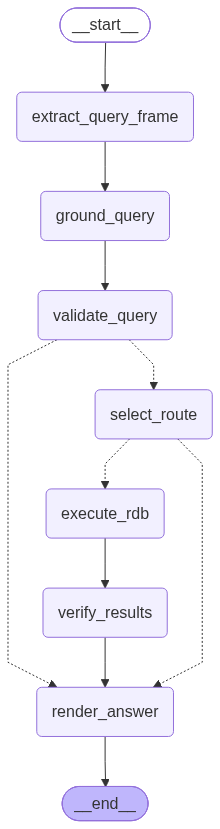

graph.png로 저장됨


In [21]:
from IPython.display import Image, display,Markdown
from agent.agent_core import APP

# 컴파일된 LangGraph 가져오기
agent_graph = APP.get_graph()

# Mermaid 그래프 정의 생성
mermaid = agent_graph.draw_mermaid()

# Jupyter에서 그래프 구조 출력
display(Markdown(mermaid))

try:
    png_bytes = agent_graph.draw_mermaid_png()
    with open("graph.png", "wb") as f:
        f.write(png_bytes)
    display(Image(png_bytes))
    print("graph.png로 저장됨")
except Exception as e:
    print("PNG 렌더링 실패 (인터넷 연결 또는 방화벽 문제일 수 있음):", e)
    print("위쪽의 mermaid 텍스트나 draw_ascii() 결과를 대신 쓰시면 됩니다.")

## `src/kb/build_rdb.py`

In [22]:
%%module kb.build_rdb kb/build_rdb.py
# -*- coding: utf-8 -*-
"""11개 CSV를 Action 3용 PostgreSQL RDB로 적재한다.

    python3 src/kb/build_rdb.py          # 재적재 후 검증
    python3 src/kb/build_rdb.py --check  # 원천과 기존 DB를 읽기 전용 검증

원본 CSV는 읽기만 한다. 타입은 schema CSV 또는 아래 고정 manifest에서만 온다.
"""
from __future__ import annotations

import argparse
import csv
import hashlib
import sys
from dataclasses import dataclass, field
from pathlib import Path

import psycopg
from psycopg import sql

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import BOND_DSN, ROOT  # noqa: E402


@dataclass(frozen=True)
class Table:
    schema: str
    name: str
    path: Path
    types: dict[str, str]
    primary_key: tuple[str, ...]
    foreign_keys: tuple[tuple[str | tuple[str, ...], str, str | tuple[str, ...]], ...] = ()
    identity: str | None = None
    skip: dict[str, frozenset[str]] = field(default_factory=dict)

    @property
    def fq(self) -> str:
        return f"{self.schema}.{self.name}"


def read_header(path: Path) -> list[str]:
    with path.open(encoding="utf-8-sig", newline="") as f:
        return next(csv.reader(f))


def raw_types(code: str) -> dict[str, str]:
    path = next((ROOT / "data/csv").glob(f"{code}_*_schema_20260824.csv"))
    with path.open(encoding="utf-8-sig", newline="") as f:
        return {r["column"].lower(): r["dtype"] for r in csv.DictReader(f)}


def text_with(path: Path, **overrides: str) -> dict[str, str]:
    types = {c.lower(): "text" for c in read_header(path)}
    unknown = set(overrides) - set(types)
    if unknown:
        raise ValueError(f"{path.name}: 타입 override 컬럼 없음 {sorted(unknown)}")
    types.update(overrides)
    return types


CSV = ROOT / "data/csv"
ENRICHED = ROOT / "data/enriched"
RELATIONS = ROOT / "data/relations"

BOND = CSV / "PRBD01N001_bond_kr_master_20260824.csv"
ETF_KR = CSV / "PREF01N001_etf_kr_master_20260824.csv"
ETF_GL = CSV / "PREF02N001_etf_gl_master_20260824.csv"
FUND = CSV / "PRFD01N001_fund_pub_master_20260824.csv"
BOND_E = ENRICHED / "bond_kr_enriched.csv"
ETF_KR_E = ENRICHED / "etf_kr_enriched.csv"
COMPANY = ENRICHED / "company_master.csv"
CODE_MAP = ENRICHED / "holding_code_map.csv"
HOLDING = RELATIONS / "etf_holding.csv"
THEME = RELATIONS / "etf_theme.csv"
SUBSIDIARY = RELATIONS / "company_subsidiary.csv"

TABLES = (
    # pd_no는 08-24 배포본에서 2,463행 중복(장내/장외·정보차수) → 복합키만 유일하다
    Table("raw", "bond_kr_master", BOND, raw_types("PRBD01N001"),
          ("pd_no", "pd_exg_mkt", "info_seq")),
    Table("raw", "etf_kr_master", ETF_KR, raw_types("PREF01N001"), ("pd_itm_no",),
          skip={"pd_itm_no": frozenset({"KR"})}),
    Table("raw", "etf_gl_master", ETF_GL, raw_types("PREF02N001"), ("pd_itm_no",)),
    # 08-24 배포본은 itm_no 단독 유일(속성코드는 prfd_attr_cds로 집약), 깨진 행 0건
    Table("raw", "fund_pub_master", FUND, raw_types("PRFD01N001"), ("itm_no",)),
    Table("enriched", "bond_kr_enriched", BOND_E, text_with(
        BOND_E, info_seq="bigint", crd_grd_rank="integer",
        remaining_days="integer", is_krw="boolean", has_sale_info="boolean",
        is_sellable="boolean"), ("pd_no", "pd_exg_mkt", "info_seq"),
        ((("pd_no", "pd_exg_mkt", "info_seq"), "raw.bond_kr_master",
          ("pd_no", "pd_exg_mkt", "info_seq")),)),
    Table("enriched", "etf_kr_enriched", ETF_KR_E, text_with(
        ETF_KR_E, ter="numeric", charge_rt_final="numeric"), ("pd_itm_no",),
        (("pd_itm_no", "raw.etf_kr_master", "pd_itm_no"),),
        skip={"pd_itm_no": frozenset({"KR"})}),
    Table("enriched", "company_master", COMPANY, text_with(COMPANY), ("corp_code",)),
    Table("enriched", "holding_code_map", CODE_MAP, text_with(CODE_MAP),
          ("holding_code_raw",),
          (("corp_code", "enriched.company_master", "corp_code"),
           ("etf_isin", "raw.etf_kr_master", "pd_itm_no"))),
    Table("relations", "etf_theme", THEME, text_with(THEME, as_of="date"),
          ("pd_itm_no", "theme"),
          (("pd_itm_no", "raw.etf_kr_master", "pd_itm_no"),)),
    Table("relations", "etf_holding", HOLDING, text_with(
        HOLDING, weight="numeric", as_of="date"), ("holding_id",),
        (("pd_itm_no", "raw.etf_kr_master", "pd_itm_no"),), "holding_id"),
    Table("relations", "company_subsidiary", SUBSIDIARY, text_with(
        SUBSIDIARY, ownership_pct="numeric", as_of="date"), ("relation_id",),
        (("parent_corp_code", "enriched.company_master", "corp_code"),
         ("child_corp_code", "enriched.company_master", "corp_code")), "relation_id"),
)
LEGACY_TABLES = ("enriched.fund_pub_dedup",)


def qname(fq: str) -> sql.Composed:
    a, b = fq.split(".")
    return sql.SQL("{}.{}").format(sql.Identifier(a), sql.Identifier(b))


def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def rows(table: Table):
    with table.path.open(encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        actual = [c.lower() for c in (reader.fieldnames or [])]
        if actual != list(table.types):
            raise ValueError(f"{table.path.name}: header/type manifest 불일치")
        for line, raw in enumerate(reader, 2):
            row = {k.lower(): v for k, v in raw.items()}
            if any(row.get(k) in vals for k, vals in table.skip.items()):
                yield line, None
            else:
                yield line, tuple(None if row[c] == "" else row[c] for c in table.types)


def validate_sources() -> dict[str, tuple[int, int]]:
    result = {}
    for table in TABLES:
        total = skipped = 0
        seen = set()
        key_ix = [list(table.types).index(k) for k in table.primary_key if k != table.identity]
        for line, row in rows(table):
            total += 1
            if row is None:
                skipped += 1
                continue
            if key_ix and table.identity is None:
                key = tuple(row[i] for i in key_ix)
                if None in key or key in seen:
                    raise ValueError(f"{table.fq}:{line} PK 오류 {key!r}")
                seen.add(key)
        result[table.fq] = (total - skipped, skipped)
        print(f"  {table.fq:39s} rows={total-skipped:,} skip={skipped} sha={sha256(table.path)[:12]}")
    return result


def create_table(conn: psycopg.Connection, table: Table) -> None:
    defs = []
    if table.identity:
        defs.append(sql.SQL("{} bigint GENERATED ALWAYS AS IDENTITY").format(
            sql.Identifier(table.identity)))
    defs += [sql.SQL("{} {}").format(sql.Identifier(c), sql.SQL(t))
             for c, t in table.types.items()]
    defs.append(sql.SQL("PRIMARY KEY ({})").format(
        sql.SQL(", ").join(map(sql.Identifier, table.primary_key))))
    for cols, ref_table, ref_cols in table.foreign_keys:
        cols = (cols,) if isinstance(cols, str) else cols
        ref_cols = (ref_cols,) if isinstance(ref_cols, str) else ref_cols
        defs.append(sql.SQL("FOREIGN KEY ({}) REFERENCES {} ({})").format(
            sql.SQL(", ").join(map(sql.Identifier, cols)), qname(ref_table),
            sql.SQL(", ").join(map(sql.Identifier, ref_cols))))
    conn.execute(sql.SQL("CREATE TABLE {} ({})").format(
        qname(table.fq), sql.SQL(", ").join(defs)))


def load(conn: psycopg.Connection, table: Table) -> int:
    cols = list(table.types)
    query = sql.SQL("COPY {} ({}) FROM STDIN").format(
        qname(table.fq), sql.SQL(", ").join(map(sql.Identifier, cols)))
    count = 0
    with conn.cursor().copy(query) as copy:
        for _, row in rows(table):
            if row is not None:
                copy.write_row(row)
                count += 1
    return count


def rebuild(expected: dict[str, tuple[int, int]]) -> None:
    with psycopg.connect(BOND_DSN) as conn:
        for schema in ("raw", "enriched", "relations"):
            conn.execute(sql.SQL("CREATE SCHEMA IF NOT EXISTS {}").format(sql.Identifier(schema)))
        for table in reversed(TABLES):
            conn.execute(sql.SQL("DROP TABLE IF EXISTS {}").format(qname(table.fq)))
        for table in LEGACY_TABLES:
            conn.execute(sql.SQL("DROP TABLE IF EXISTS {}").format(qname(table)))
        for table in TABLES:
            create_table(conn, table)
            actual = load(conn, table)
            if actual != expected[table.fq][0]:
                raise RuntimeError(f"{table.fq}: 적재 {actual} != 기대 {expected[table.fq][0]}")
            print(f"  loaded {table.fq:32s} {actual:,}")


def validate_db(expected: dict[str, tuple[int, int]]) -> None:
    with psycopg.connect(BOND_DSN) as conn:
        actual_tables = {".".join(row) for row in conn.execute("""
            SELECT table_schema, table_name FROM information_schema.tables
            WHERE table_schema IN ('raw','enriched','relations')
              AND table_type = 'BASE TABLE'
        """).fetchall()}
        expected_tables = {table.fq for table in TABLES}
        if actual_tables != expected_tables:
            raise RuntimeError(f"DB table 집합 불일치: {sorted(actual_tables ^ expected_tables)}")
        for table in TABLES:
            n = conn.execute(sql.SQL("SELECT count(*) FROM {}").format(qname(table.fq))).fetchone()[0]
            if n != expected[table.fq][0]:
                raise RuntimeError(f"{table.fq}: DB {n} != 원천 {expected[table.fq][0]}")
        cutoff_bad = conn.execute("""
            SELECT count(*) FROM (
              SELECT as_of FROM relations.etf_theme
              UNION ALL SELECT as_of FROM relations.etf_holding
              UNION ALL SELECT as_of FROM relations.company_subsidiary
            ) x WHERE as_of > DATE '2026-08-24'
        """).fetchone()[0]
        if cutoff_bad:
            raise RuntimeError(f"as_of cutoff 초과 {cutoff_bad}행")
        constraints = conn.execute("""
            SELECT count(*) FROM information_schema.table_constraints
            WHERE table_schema IN ('raw','enriched','relations')
              AND constraint_type IN ('PRIMARY KEY','FOREIGN KEY')
        """).fetchone()[0]
        want = len(TABLES) + sum(len(t.foreign_keys) for t in TABLES)
        if constraints < want:
            raise RuntimeError(f"PK/FK 제약 부족: {constraints} < {want}")
    print(f"PASS DB 검증 — {len(TABLES)} tables, PK/FK {constraints}, cutoff 위반 0")


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--check", action="store_true")
    args = ap.parse_args()
    print("원천 검증")
    expected = validate_sources()
    if not args.check:
        print("PostgreSQL 적재")
        rebuild(expected)
    print("PostgreSQL 검증")
    validate_db(expected)


if __name__ == "__main__":
    main()


registered: kb.build_rdb


## `src/kb/build_graph.py`

In [23]:
%%module kb.build_graph kb/build_graph.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""현재 TTL 10개를 persistent pyoxigraph Store로 구축·검증한다."""
from __future__ import annotations

import argparse
import json
import sys
import tempfile
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import ARTIFACTS, ROOT  # noqa: E402

try:
    from pyoxigraph import RdfFormat, Store
except ImportError as exc:  # pragma: no cover - 설치 안내 경로
    raise SystemExit("pyoxigraph 미설치 — python3 -m pip install -r requirements.txt") from exc

CUTOFF = "2026-08-24"
OUT = ARTIFACTS / "oxigraph"
MANIFEST = OUT / "manifest.json"
TBOX = ("common.ttl", "bond_kr.ttl", "etf_kr.ttl", "etf_gl.ttl", "fund_pub.ttl")
ABOX = ("instances_bond_kr.ttl", "instances_etf_kr.ttl", "instances_etf_gl.ttl",
        "instances_fund_pub.ttl", "instances_company.ttl")
FILES = TBOX + ABOX

PREFIX = """
PREFIX fp: <http://mafest.ai/product#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
"""
REQUIRED_PATH = PREFIX + """
ASK {
  ?parent fp:hasSubsidiary ?relation .
  ?relation fp:subsidiaryCompany ?company .
  ?security fp:issuedByCompany ?company .
  ?holding fp:holdingSecurity ?security .
  ?etf fp:hasHolding ?holding .
}
"""
FUTURE_COUNT = PREFIX + f"""
SELECT (COUNT(?node) AS ?count) WHERE {{
  ?node fp:asOf ?as_of .
  FILTER (?as_of > \"{CUTOFF}\"^^xsd:date)
}}
"""
DROP_FUTURE = PREFIX + f"""
DELETE {{ ?node ?predicate ?object . ?subject ?incoming ?node }} WHERE {{
  ?node fp:asOf ?as_of .
  FILTER (?as_of > \"{CUTOFF}\"^^xsd:date)
  {{ ?node ?predicate ?object }} UNION {{ ?subject ?incoming ?node }}
}}
"""


def inputs() -> list[Path]:
    paths = [ROOT / "ontology" / name for name in FILES]
    missing = [str(path.relative_to(ROOT)) for path in paths if not path.is_file()]
    if missing:
        raise ValueError("TTL 입력 누락: " + ", ".join(missing))
    return paths


def _scalar(store: Store, query: str, name: str) -> int:
    row = next(iter(store.query(query)))
    return int(row[name].value)


def validate_store(store: Store) -> dict:
    triples = len(store)
    if not triples:
        raise ValueError("Oxigraph store가 비어 있습니다")
    if not bool(store.query(REQUIRED_PATH)):
        raise ValueError("필수 Graph 경로 Company→Subsidiary→Security→Holding→ETF가 없습니다")
    future = _scalar(store, FUTURE_COUNT, "count")
    if future:
        raise ValueError(f"fp:asOf가 cutoff {CUTOFF}를 넘는 노드 {future:,}건")
    return {"triple_count": triples, "future_as_of_count": future, "cutoff": CUTOFF,
            "ttl_files": list(FILES)}


def build() -> dict:
    paths = inputs()
    ARTIFACTS.mkdir(exist_ok=True)
    if OUT.exists():
        raise FileExistsError(f"기존 store를 덮어쓰지 않습니다: {OUT}")
    with tempfile.TemporaryDirectory(prefix=".oxigraph-", dir=ARTIFACTS) as tmp:
        candidate = Path(tmp) / "store"
        store = Store(str(candidate))
        for path in paths:
            store.bulk_load(path=str(path), format=RdfFormat.TURTLE)
            print(f"load {path.relative_to(ROOT)}")
        excluded = _scalar(store, FUTURE_COUNT, "count")
        if excluded:
            store.update(DROP_FUTURE)
            print(f"exclude future relation nodes: {excluded:,}")
        store.flush()
        result = validate_store(store)
        result["excluded_future_nodes"] = excluded
        del store
        candidate.replace(OUT)
    MANIFEST.write_text(json.dumps(result, ensure_ascii=False, indent=2) + "\n",
                        encoding="utf-8")
    return result


def check() -> dict:
    inputs()
    if not OUT.is_dir():
        raise ValueError(f"Graph store가 없습니다: {OUT}")
    return validate_store(Store.read_only(str(OUT)))


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--check", action="store_true")
    args = parser.parse_args()
    result = check() if args.check else build()
    print("PASS " + json.dumps(result, ensure_ascii=False))


if __name__ == "__main__":
    main()


registered: kb.build_graph


## `src/kb/build_schema_catalog.py`

In [24]:
%%module kb.build_schema_catalog kb/build_schema_catalog.py
# -*- coding: utf-8 -*-
"""RDB manifest → compact catalog, verified binding 정적 검증.

    python3 src/kb/build_schema_catalog.py          # artifact 생성 + 검증
    python3 src/kb/build_schema_catalog.py --check  # 쓰기 없이 검증

운영 binding은 사람이 검토한 metadata/*.json이 정본이다. 이 스크립트는 그 식별자가
실제 적재 manifest와 TBox에 존재하는지만 확인하며 gold SQL은 읽지 않는다.
"""
from __future__ import annotations

import argparse
import csv
import io
import json
import sys
from pathlib import Path

from rdflib import Graph, URIRef

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import ARTIFACTS, ROOT  # noqa: E402
from kb.build_rdb import TABLES, rows  # noqa: E402

BINDINGS = ROOT / "metadata/schema_bindings.json"
RULES = ROOT / "metadata/business_rules.json"
OUT = ARTIFACTS / "schema_catalog.json"
TABLE_DEF = ROOT / "data/table_definition_v1_0.csv"
FP = "http://mafest.ai/product#"

TABLE_META = {
    "raw.bond_kr_master": ("국내채권 원본 마스터", "채권 거래·정보차수 1건/행", "2026-08-21 (info_base_dt)", "organizer", "원본 CSV 무변경 적재", "PK=(pd_no,pd_exg_mkt,info_seq); pd_no 중복 그룹 포함 행 2,463건"),
    "raw.etf_kr_master": ("국내 ETF·ETN 원본 마스터", "상품 1건/행", "2026-08-21 (가격·기준가)", "organizer", "원본 CSV 무변경 적재", "ETF 질의는 pd_grp_no='ETF' 필수"),
    "raw.etf_gl_master": ("해외 ETF·ETN 원본 마스터", "상품 1건/행", "2026-08-21 (종가 최빈값; 행별 기준일)", "organizer", "원본 CSV 무변경 적재", "문장형 sentinel은 NULL 취급 필요"),
    "raw.fund_pub_master": ("펀드 원본 마스터", "펀드 1건/행", "2026-08-21 (원천에 기준일 컬럼 없음)", "organizer", "원본 CSV 무변경 적재", "itm_no PK; prfd_attr_cds는 원천에 집약된 속성 목록"),
    "enriched.bond_kr_enriched": ("채권 등급·잔존만기·만기미도래 파생", "채권 거래·정보차수 1건/행", "2026-08-21 (잔존만기 재계산)", "derived_from_organizer", "채권 원본에서 결정적으로 파생", "PK/FK=(pd_no,pd_exg_mkt,info_seq); 등급 rank 1~19"),
    "enriched.etf_kr_enriched": ("국내 ETF·ETN LSEG 스칼라 보강", "상품 1건/행", "LSEG 수집시점 미확인", "organizer_then_external", "주최측 실값 우선, 결측·0.0 더미만 LSEG 보완", "pd_itm_no='KR' 1행 제외; charge_rt_source 필수"),
    "enriched.company_master": ("DART 기업 고유번호 마스터", "기업 1건/행", "2026-08-24 이하", "external", "DART corpCode와 KIND에서 생성", "corp_code PK; 법인명 정규화 규칙 고정"),
    "enriched.holding_code_map": ("편입종목 식별자 해소표", "원본 편입코드 1건/행", "2026-07-10", "derived", "정확히 확정 가능한 ticker·ETF·우선주만 매핑", "미해소는 공란 유지; match_rule 보존"),
    "relations.etf_theme": ("국내 ETF-테마 관계", "ETF-테마 1건/행", "확인할 수 없음", "external", "LSEG themes를 롱포맷 변환", "as_of 추정 금지"),
    "relations.etf_holding": ("국내 ETF-편입종목 관계", "ETF-편입종목 1건/행", "2026-07-10", "external", "운용사 원천을 공통 롱포맷으로 변환", "룩어헤드 현재가·등락 제외; holding_id identity"),
    "relations.company_subsidiary": ("기업-자회사 출자 관계", "출자관계 1건/행", "공시 접수일 (2026-08-24 이하)", "external", "DART 타법인출자현황을 롱포맷 변환", "미확정 자회사 코드는 공란; relation_id identity"),
}

VECTOR_TABLES = (
    ("bond_schema_terms", 130, "common.ttl + bond_kr.ttl", "운영 채권 TBox 인덱스"),
    ("schema_terms_all", 188, "TBox 5개 TTL", "평가용 전체 도메인 TBox 인덱스"),
)


def load(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def catalog() -> dict:
    return {
        "version": 1,
        "tables": [
            {
                "table": t.fq,
                "columns": ([{"name": t.identity, "datatype": "bigint"}]
                            if t.identity else [])
                           + [{"name": n, "datatype": dt} for n, dt in t.types.items()],
                "primary_key": list(t.primary_key),
                "foreign_keys": [
                    {"columns": list(c) if isinstance(c, tuple) else [c],
                     "references_table": rt,
                     "references_columns": list(rc) if isinstance(rc, tuple) else [rc]}
                    for c, rt, rc in t.foreign_keys
                ],
            }
            for t in TABLES
        ],
    }


def source_labels(table: str) -> dict[str, str]:
    codes = {
        "raw.bond_kr_master": "PRBD01N001", "enriched.bond_kr_enriched": "PRBD01N001",
        "raw.etf_kr_master": "PREF01N001", "enriched.etf_kr_enriched": "PREF01N001",
        "raw.etf_gl_master": "PREF02N001",
        "raw.fund_pub_master": "PRFD01N001",
    }
    code = codes.get(table)
    if not code:
        return {}
    path = next((ROOT / "data/csv").glob(f"{code}_*_schema_20260824.csv"))
    with path.open(encoding="utf-8-sig", newline="") as f:
        return {r["column"].lower(): r["comment_ko"] for r in csv.DictReader(f)}


def table_definition(metadata: dict) -> list[dict[str, object]]:
    binding = {(b["table"], b["column"]): b for b in metadata.get("bindings", [])}
    out = []
    for table in TABLES:
        desc, grain, as_of, priority, transform, quality = TABLE_META[table.fq]
        labels = source_labels(table.fq)
        fks = {
            c: f"{rt}.{'/'.join(rc if isinstance(rc, tuple) else (rc,))}"
            for cols, rt, rc in table.foreign_keys
            for c in (cols if isinstance(cols, tuple) else (cols,))
        }
        columns = ([(table.identity, "bigint")] if table.identity else []) + list(table.types.items())
        row_count = sum(row is not None for _, row in rows(table))
        for order, (name, datatype) in enumerate(columns, 1):
            b = binding.get((table.fq, name), {})
            out.append({
                "store": "PostgreSQL/RDB", "schema": table.schema, "table": table.name,
                "table_description": desc, "grain": grain,
                "source_file": str(table.path.relative_to(ROOT)), "row_count": row_count,
                "column_order": order, "column_name": name,
                "column_description": b.get("label") or labels.get(name) or "확인할 수 없음",
                "data_type": datatype, "nullable": "N" if name in table.primary_key else "Y",
                "primary_key": "Y" if name in table.primary_key else "N",
                "foreign_key": fks.get(name, ""), "unit": b.get("unit", ""),
                "as_of_basis": as_of, "source_priority": priority,
                "transformation_rule": transform, "quality_rule": quality,
                "implementation_status": "live DB 검증 완료 (2026-08-24)",
            })
    for name, count, source, desc in VECTOR_TABLES:
        columns = (("term_uri", "text", "용어 URI", "N", "Y"),
                   ("label", "text", "대표 라벨", "N", "N"),
                   ("comment", "text", "TBox 설명", "N", "N"),
                   ("alt_labels", "text[]", "대체 라벨", "N", "N"),
                   ("content", "text", "임베딩 입력 텍스트", "N", "N"),
                   ("embedding", "vector(1024)", "CLOVA Studio bge-m3 임베딩", "N", "N"))
        for order, (column, datatype, column_desc, nullable, pk) in enumerate(columns, 1):
            out.append({
                "store": "PostgreSQL/pgvector", "schema": "public", "table": name,
                "table_description": desc, "grain": "TBox resource 1건/행",
                "source_file": source, "row_count": count, "column_order": order,
                "column_name": column, "column_description": column_desc,
                "data_type": datatype, "nullable": nullable, "primary_key": pk,
                "foreign_key": "", "unit": "", "as_of_basis": "ontology schema version",
                "source_priority": "ontology", "transformation_rule": "URI·label·altLabel·comment 결합 후 임베딩",
                "quality_rule": "rdfs:comment 없는 resource 제외; embedding 1024차원",
                "implementation_status": "live DB 검증 완료 (2026-08-24)",
            })
    return out


def write_table_definition(rows: list[dict[str, object]]) -> None:
    buf = io.StringIO(newline="")
    writer = csv.DictWriter(buf, fieldnames=list(rows[0]), lineterminator="\n")
    writer.writeheader()
    writer.writerows(rows)
    TABLE_DEF.parent.mkdir(parents=True, exist_ok=True)
    TABLE_DEF.write_bytes(b"\xef\xbb\xbf" + buf.getvalue().encode("utf-8"))


def tbox_uris() -> set[str]:
    graph = Graph()
    for name in ("common.ttl", "bond_kr.ttl", "etf_kr.ttl", "etf_gl.ttl", "fund_pub.ttl"):
        graph.parse(ROOT / "ontology" / name, format="turtle")
    return {f"fp:{str(s).split('#')[-1]}" for s in set(graph.subjects())
            if isinstance(s, URIRef) and str(s).startswith(FP)}


def validate(cat: dict, metadata: dict, rules: dict) -> None:
    tables = {t["table"]: {c["name"] for c in t["columns"]} for t in cat["tables"]}
    bindings = metadata.get("bindings") or []
    ids = [b["id"] for b in bindings]
    if len(ids) != len(set(ids)):
        raise ValueError("binding id 중복")
    domains = set(metadata.get("domains") or {})
    uris = tbox_uris()
    bad = []
    for b in bindings:
        if b["domain"] not in domains:
            bad.append(f"{b['id']}: 알 수 없는 domain {b['domain']}")
        if b["table"] not in tables or b["column"] not in tables.get(b["table"], set()):
            bad.append(f"{b['id']}: 없는 source {b['table']}.{b['column']}")
        if b.get("concept_uri") and b["concept_uri"] not in uris:
            bad.append(f"{b['id']}: TBox에 없는 concept {b['concept_uri']}")
        if not set(b["usage"]) <= {"select", "filter", "sort"}:
            bad.append(f"{b['id']}: usage 오류 {b['usage']}")
    for d, spec in metadata["domains"].items():
        if spec["base_table"] not in tables:
            bad.append(f"{d}: 없는 base_table {spec['base_table']}")
        for key in ("id", "name"):
            if spec[key] not in ids:
                bad.append(f"{d}: 없는 {key} binding {spec[key]}")
    for j in metadata.get("joins") or []:
        left_keys = j.get("left_keys") or [j.get("left_key")]
        right_keys = j.get("right_keys") or [j.get("right_key")]
        if len(left_keys) != len(right_keys) or not left_keys:
            bad.append(f"JOIN key 수 오류 {j['left']} ↔ {j['right']}")
        for key in left_keys:
            if j["left"] not in tables or key not in tables.get(j["left"], set()):
                bad.append(f"JOIN left 오류 {j['left']}.{key}")
        for key in right_keys:
            if j["right"] not in tables or key not in tables.get(j["right"], set()):
                bad.append(f"JOIN right 오류 {j['right']}.{key}")
    paths = {f"{b['table']}.{b['column']}" for b in bindings}
    forbidden = set(rules["forbidden_columns"])
    if paths & forbidden:
        bad.append(f"금지 컬럼 binding {sorted(paths & forbidden)}")
    referenced = {
        x["binding"]
        for xs in rules.get("mandatory_filters", {}).values() for x in xs
    } | {
        x["binding"]
        for r in rules.get("target_filters", []) for x in r["filters"]
    } | {
        x["binding"]
        for xs in rules.get("default_order", {}).values() for x in xs
    }
    missing = referenced - set(ids)
    if missing:
        bad.append(f"rule이 없는 binding 참조 {sorted(missing)}")
    if rules.get("data_cutoff") != "2026-07-11":
        bad.append("data cutoff는 2026-07-11이어야 함")
    cutoff = rules.get("data_cutoff", "")
    for domain, item in rules.get("domain_as_of", {}).items():
        if item.get("value", "") > cutoff:
            bad.append(f"{domain}: as_of {item['value']}가 cutoff {cutoff} 이후")
    if bad:
        raise ValueError("\n".join(bad))
    print(f"PASS schema catalog — tables={len(tables)} bindings={len(bindings)} "
          f"joins={len(metadata.get('joins') or [])} forbidden=0")


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--check", action="store_true")
    args = ap.parse_args()
    cat, metadata, rules = catalog(), load(BINDINGS), load(RULES)
    validate(cat, metadata, rules)
    if not args.check:
        OUT.parent.mkdir(exist_ok=True)
        OUT.write_text(json.dumps(cat, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
        print(f"catalog → {OUT.relative_to(ROOT)}")
        rows = table_definition(metadata)
        write_table_definition(rows)
        print(f"table definition → {TABLE_DEF.relative_to(ROOT)} ({len(rows)} columns)")


if __name__ == "__main__":
    main()


registered: kb.build_schema_catalog


## `src/kb/build_bond_index.py`

In [25]:
%%module kb.build_bond_index kb/build_bond_index.py
# -*- coding: utf-8 -*-
"""채권 스키마 TTL → pgvector 인덱스.

    python3 kb/build_bond_index.py

TTL을 일반 문서처럼 자르지 않는다. resource 1개 = vector 1개다.
각 resource에서 URI · rdfs:label · skos:altLabel · rdfs:comment 를 읽어 한 줄로 만든다.

    fp:riskGradeLevel | 위험등급 수준 | 1=최고위험 … 6=최저위험.

주석(rdfs:comment)이 없는 resource는 넣지 않는다. 이 인덱스의 목적은 "안전한" 같은 말을
fp: 용어로 번역하는 것이고, 번역 근거가 되는 게 주석이기 때문이다. 또 답변 단계
(agent/nodes.py)가 "comment 안에 적힌 문장만 근거로 삼는다"고 규정하므로, 주석 없는
용어는 검색에 걸려도 근거로 쓸 수 없고 Top-K 슬롯만 차지한다.

  ※ 주석 없는 코드리스트 개체 91건을 넣어 본 실측 결과는
     vectordb_test/3_baseline_130_v2/baseline_130_v2_report.md 에 있다.
     Top-1 -9, 근거 커버리지 100% → 68.6% 로 나빠져 현재 형태로는 넣지 않기로 했다.

저장소는 PostgreSQL + pgvector 다(FAISS 에서 이전). 벡터는 정규화하지 않고 원본을 넣는다 —
cosine 연산자(<=>)가 내부에서 처리하므로 결과가 같고, 정규화 단계가 하나 줄어든다.
"""
import json
import sys
import time
from pathlib import Path

import psycopg
from rdflib import RDFS, Graph, Namespace, URIRef

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from config import (ARTIFACTS, BOND_DSN, BOND_TABLE, BOND_TTL_PATHS,  # noqa: E402
                    EMBED_DIM)
import clova  # noqa: E402

FP = Namespace("http://mafest.ai/product#")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
TERMS_JSON = ARTIFACTS / "bond_terms.json"      # 측정 하네스(vectordb_test)가 읽는 교환 파일


def pick(g, s, prop, lang="ko"):
    """같은 프로퍼티에 여러 언어가 있으면 한국어 우선."""
    vals = list(g.objects(s, prop))
    if not vals:
        return ""
    ko = [str(v) for v in vals if getattr(v, "language", None) == lang]
    return (ko or [str(v) for v in vals])[0]


def collect():
    """주석 있는 fp: resource 를 URI 정렬 순서로 모은다.

    정렬은 재현성 때문이다 — rdflib 의 subjects() 순서는 비결정적이라, 정렬하지 않으면
    재빌드마다 적재 순서가 달라져 diff 가 무의미해진다. 다만 순서가 식별자는 아니다.
    pgvector 는 term_uri 가 PK 이므로 순서가 바뀌어도 검색 결과는 같다.
    """
    g = Graph()
    for p in BOND_TTL_PATHS:
        g.parse(p, format="turtle")
    subs = {s for s in g.subjects(RDFS.comment, None)
            if isinstance(s, URIRef) and str(s).startswith(str(FP))}
    terms = []
    for s in sorted(subs, key=str):
        uri = f"fp:{str(s).split('#')[-1]}"
        label = pick(g, s, RDFS.label)
        comment = pick(g, s, RDFS.comment)
        alts = sorted(str(o) for o in g.objects(s, SKOS.altLabel))
        # altLabel 을 검색 텍스트에 넣는다. 사용자는 '무등급'이라 쓰고 라벨은 'NotRated'인 경우가 있다.
        text = " | ".join(x for x in [uri, label, " / ".join(alts), comment] if x)
        terms.append({"term_uri": uri, "label": label, "comment": comment,
                      "alt_labels": alts, "text": text})
    return terms


def main():
    t0 = time.time()
    terms = collect()
    print(f"resource {len(terms)}개 수집 ({', '.join(p.name for p in BOND_TTL_PATHS)})")

    vecs = clova.embed_many([t["text"] for t in terms])
    if len(vecs) != len(terms):
        sys.exit(f"FAIL 임베딩 개수 불일치: {len(vecs)} vs {len(terms)}")
    if len(vecs[0]) != EMBED_DIM:
        sys.exit(f"FAIL 차원 불일치: {len(vecs[0])} (기대 {EMBED_DIM})")

    with psycopg.connect(BOND_DSN, autocommit=True) as conn:
        conn.execute("CREATE EXTENSION IF NOT EXISTS vector")
        conn.execute(f"DROP TABLE IF EXISTS {BOND_TABLE}")
        conn.execute(f"""
            CREATE TABLE {BOND_TABLE} (
                term_uri   text PRIMARY KEY,
                label      text NOT NULL,
                comment    text NOT NULL,
                alt_labels text[] NOT NULL DEFAULT '{{}}',
                content    text NOT NULL,
                embedding  vector({EMBED_DIM}) NOT NULL
            )""")
        with conn.cursor() as cur:
            cur.executemany(
                f"INSERT INTO {BOND_TABLE}"
                " (term_uri,label,comment,alt_labels,content,embedding)"
                " VALUES (%s,%s,%s,%s,%s,%s::vector)",
                [(t["term_uri"], t["label"], t["comment"], t["alt_labels"], t["text"],
                  str(list(map(float, v)))) for t, v in zip(terms, vecs)])

        n, dim, nulls = conn.execute(
            f"SELECT count(*), max(vector_dims(embedding)), count(*) FILTER"
            f" (WHERE embedding IS NULL) FROM {BOND_TABLE}").fetchone()

    if n != len(terms) or dim != EMBED_DIM or nulls:
        sys.exit(f"FAIL 적재 검증: {n}행 / {dim}차원 / NULL {nulls}")

    ARTIFACTS.mkdir(exist_ok=True)
    TERMS_JSON.write_text(json.dumps(terms, ensure_ascii=False, indent=1), encoding="utf-8")

    print(f"  {BOND_TABLE:20s} {n}행 × {dim}차원  (NULL {nulls})")
    print(f"  {TERMS_JSON.name:20s} {TERMS_JSON.stat().st_size/1024:.0f}KB")
    print(f"소요 {time.time()-t0:.1f}s")


if __name__ == "__main__":
    main()


registered: kb.build_bond_index


# 노드별 테스트

아래는 LangGraph 를 거치지 않고 노드 함수를 하나씩 실행하는 셀이다.
위의 모듈 셀을 수정했다면 해당 셀 → `agent.nodes` 셀 → 여기 순서로 재실행한다.

In [26]:
from agent import nodes as N

TEST_QUESTION = "현대해상화재보험7(후)(콜/후)의 채권 종류, 발행사, 신용등급, 만기구분, 듀레이션을 알려줘. 원본 등급값과 온톨로지 분류값을 함께 제시해줘"  # 예: expected_qa 의 채권 문항

state = {"question_id": "test", "question": TEST_QUESTION, "intent": {},
         "metadata_context": {}, "plan": {}, "route": {}, "results": {}, "evidence": [],
         "abstain": None, "trace": [], "answer": ""}

In [27]:
out = N.extract_query_frame(state); state.update(out); out

{'intent': {'domain_candidates': ['bond_kr'],
  'task': 'lookup',
  'targets': [{'text': '채권'}],
  'entities': [{'text': '현대해상화재보험7(후)(콜/후)',
    'role': 'product',
    'match_mode': 'exact'}],
  'requested_fields': [{'text': '채권 종류'},
   {'text': '발행사'},
   {'text': '신용등급'},
   {'text': '만기구분'},
   {'text': '듀레이션'}],
  'constraints': [],
  'relations': [],
  'ordering': [],
  'limit': None,
  'temporal': {'kind': 'latest_snapshot',
   'raw': None,
   'as_of_text': None,
   'window_text': None},
  'computation': [],
  'evidence_requirements': [],
  'ambiguity': [],
  'validation_targets': [],
  '_guard': [],
  '_raw': {'domain_candidates': ['bond_kr'],
   'task': 'lookup',
   'targets': [{'text': '채권'}],
   'entities': [{'text': '현대해상화재보험7(후)(콜/후)',
     'role': 'product',
     'match_mode': 'exact'}],
   'requested_fields': [{'text': '채권 종류'},
    {'text': '발행사'},
    {'text': '신용등급'},
    {'text': '만기구분'},
    {'text': '듀레이션'}],
   'constraints': [],
   'relations': [],
   'ordering'

In [28]:
out = N.ground_query(state); state.update(out); out

{'metadata_context': {'domain': 'bond_kr',
  'task': 'lookup',
  'entities': [{'mode': 'exact',
    'binding': 'bond.product_name',
    'value': '현대해상화재보험7(후)(콜/후)'}],
  'select': ['bond.product_code',
   'bond.product_name',
   'bond.type',
   'bond.issuer',
   'bond.credit_rating',
   'bond.maturity_bucket',
   'bond.duration',
   'bond.rating_norm'],
  'filters': [],
  'order': [],
  'limit': None,
  'unresolved': [],
  'concepts': ['fp:productCode',
   'fp:productName',
   'fp:bondKind',
   'fp:issuedBy',
   'fp:creditRatingLabel',
   'fp:maturityBucket',
   'fp:duration'],
  'as_of': {'value': '2026-08-21',
   'basis': 'raw.bond_kr_master.info_base_dt (2026-08-24 배포본)'}},
 'plan': {'domain': 'bond_kr',
  'task': 'lookup',
  'entities': [{'mode': 'exact',
    'binding': 'bond.product_name',
    'value': '현대해상화재보험7(후)(콜/후)'}],
  'select': ['bond.product_code',
   'bond.product_name',
   'bond.type',
   'bond.issuer',
   'bond.credit_rating',
   'bond.maturity_bucket',
   'bond.durat

In [29]:
out = N.validate_query(state); state.update(out); out
# state["abstain"] 이 있으면 이후는 render_answer 로 직행하는 경로다

{'abstain': None,
 'trace': ["intent: task=lookup domain=['bond_kr'] entities=1 constraints=0",
  "grounding: domain=bond_kr concepts=['fp:productCode', 'fp:productName', 'fp:bondKind', 'fp:issuedBy', 'fp:creditRatingLabel', 'fp:maturityBucket', 'fp:duration'] unresolved=0",
  'validation: PASS']}

In [30]:
out = N.select_route(state); state.update(out); out

{'route': {'query_type': 'rdb_only',
  'execution_plan': [{'id': 'A', 'engine': 'rdb', 'depends_on': []}],
  'reason': 'verified single-domain RDB capability'},
 'abstain': None,
 'trace': ["intent: task=lookup domain=['bond_kr'] entities=1 constraints=0",
  "grounding: domain=bond_kr concepts=['fp:productCode', 'fp:productName', 'fp:bondKind', 'fp:issuedBy', 'fp:creditRatingLabel', 'fp:maturityBucket', 'fp:duration'] unresolved=0",
  'validation: PASS',
  'route: rdb_only steps=1 — verified single-domain RDB capability']}

In [31]:
out = N.execute_rdb(state); state.update(out); out

{'results': {'rows': [{'pd_no': 'KR6001451F34',
    'pd_nm': '현대해상화재보험7(후)(콜/후)',
    'bd_knd': '보험회사채',
    'pd_pbcm': '현대해상화재보험(주)',
    'crd_grd': 'AA0',
    'maturity_bucket': '5-10년',
    'dur': 4.3459,
    'crd_grd_norm': 'AA'}],
  'columns': ['pd_no',
   'pd_nm',
   'bd_knd',
   'pd_pbcm',
   'crd_grd',
   'maturity_bucket',
   'dur',
   'crd_grd_norm'],
  'evidence': [{'binding': 'bond.product_code',
    'label': '상품번호',
    'source_table': 'raw.bond_kr_master',
    'source_column': 'pd_no',
    'as_of': '2026-08-21',
    'as_of_basis': 'raw.bond_kr_master.info_base_dt (2026-08-24 배포본)',
    'source_kind': 'organizer'},
   {'binding': 'bond.product_name',
    'label': '상품명',
    'source_table': 'raw.bond_kr_master',
    'source_column': 'pd_nm',
    'as_of': '2026-08-21',
    'as_of_basis': 'raw.bond_kr_master.info_base_dt (2026-08-24 배포본)',
    'source_kind': 'organizer'},
   {'binding': 'bond.type',
    'label': '채권 종류',
    'source_table': 'raw.bond_kr_master',
    'source_c

In [32]:
out = N.verify_results(state); state.update(out); out

{'abstain': None,
 'trace': ["intent: task=lookup domain=['bond_kr'] entities=1 constraints=0",
  "grounding: domain=bond_kr concepts=['fp:productCode', 'fp:productName', 'fp:bondKind', 'fp:issuedBy', 'fp:creditRatingLabel', 'fp:maturityBucket', 'fp:duration'] unresolved=0",
  'validation: PASS',
  'route: rdb_only steps=1 — verified single-domain RDB capability',
  'rdb: rows=1 status=PASS',
  'verify: PASS']}

In [33]:
out = N.render_answer(state); state.update(out)
print(state["answer"])

상품번호=KR6001451F34 [raw.bond_kr_master.pd_no, 기준일 2026-08-21]; 상품명=현대해상화재보험7(후)(콜/후) [raw.bond_kr_master.pd_nm, 기준일 2026-08-21]; 채권 종류=보험회사채 [raw.bond_kr_master.bd_knd, 기준일 2026-08-21]; 발행사=현대해상화재보험(주) [raw.bond_kr_master.pd_pbcm, 기준일 2026-08-21]; 원신용등급=AA0 [raw.bond_kr_master.crd_grd, 기준일 2026-08-21]; 만기구분=5-10년 [enriched.bond_kr_enriched.maturity_bucket, 기준일 2026-08-21]; 듀레이션=4.3459 [raw.bond_kr_master.dur, 기준일 2026-08-21]; 온톨로지 신용등급=AA [enriched.bond_kr_enriched.crd_grd_norm, 기준일 2026-08-21]


## 전체 그래프 E2E

In [35]:
from agent.agent_core import ask

TEST_QUESTION = "현대해상화재보험7(후)(콜/후)의 채권 종류, 발행사, 신용등급, 만기구분, 듀레이션을 알려줘. 원본 등급값과 온톨로지 분류값을 함께 제시해줘"  # 예: expected_qa 의 채권 문항

result = ask(TEST_QUESTION)
result

{'question_id': '',
 'question': '현대해상화재보험7(후)(콜/후)의 채권 종류, 발행사, 신용등급, 만기구분, 듀레이션을 알려줘. 원본 등급값과 온톨로지 분류값을 함께 제시해줘',
 'retrieved_context': [{'binding': 'bond.product_code',
   'label': '상품번호',
   'source_table': 'raw.bond_kr_master',
   'source_column': 'pd_no',
   'as_of': '2026-08-21',
   'as_of_basis': 'raw.bond_kr_master.info_base_dt (2026-08-24 배포본)',
   'source_kind': 'organizer'},
  {'binding': 'bond.product_name',
   'label': '상품명',
   'source_table': 'raw.bond_kr_master',
   'source_column': 'pd_nm',
   'as_of': '2026-08-21',
   'as_of_basis': 'raw.bond_kr_master.info_base_dt (2026-08-24 배포본)',
   'source_kind': 'organizer'},
  {'binding': 'bond.type',
   'label': '채권 종류',
   'source_table': 'raw.bond_kr_master',
   'source_column': 'bd_knd',
   'as_of': '2026-08-21',
   'as_of_basis': 'raw.bond_kr_master.info_base_dt (2026-08-24 배포본)',
   'source_kind': 'organizer'},
  {'binding': 'bond.issuer',
   'label': '발행사',
   'source_table': 'raw.bond_kr_master',
   'source_column': 'p

## .py 반영

셀 수정 후 **노트북 저장(Ctrl+S)** → 아래 실행.

In [ ]:
# sync_to_py()                # diff 확인
# sync_to_py(dry_run=False)   # 실제 반영